# Preprocesado de datos financieros para ML

In [1]:
# Librerías de lectura de los datos
import kagglehub
from binance_historical_data import BinanceDataDumper
import glob
from pathlib import Path

import pandas as pd
import numpy as np
import random
import os
import shutil
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import KFold

# Librerías de gráficos
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import matplotlib.dates as mdates

from statsmodels.tsa.stattools import adfuller

c:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ModuleNotFoundError: No module named 'binance_historical_data'

In [ ]:
import gc
gc.collect()

0

# 0. Lectura de datos

## 0.1. Lectura de datos BTC (kagglehub)

Proceso de lectura y filtrado de datos de los precios de Bitcoin desde el año 2012 con un datos cada 1 minuto

In [ ]:
# # Imports básicos del proyecto

# # Configuración de estilo básica para las figuras de matplotlib
# plt.style.use("default")  # Fondo blanco por defecto

# # ======================================================================
# # ### PARÁMETROS ###
# # ----------------------------------------------------------------------
# # Rango temporal de análisis (el usuario solo debería modificar estas dos
# # variables para cambiar el periodo de trabajo del notebook).
# # ======================================================================
# DATE_START = "2026-02-01"
# # DATE_START = "2022-01-01"
# DATE_END   = "2026-02-28"

# print("Rango temporal configurado:")
# print(f"  Fecha inicio: {DATE_START}")
# print(f"  Fecha fin   : {DATE_END}")

Descargamos los datos desde kaggle y lo reasignamos al escritorio activo.

In [ ]:
# # Descarga del dataset de Kaggle y localización del archivo CSV principal

# # Código de descarga fijado por el enunciado (no modificar)
# path = kagglehub.dataset_download("mczielinski/bitcoin-historical-data")
# print("Path to dataset files:", path)

# # Búsqueda recursiva de todos los archivos CSV dentro del path descargado
# csv_pattern = os.path.join(path, "**", "*.csv")
# csv_files = glob.glob(csv_pattern, recursive=True)

# if not csv_files:
#     raise FileNotFoundError("No se encontraron archivos CSV en la ruta descargada de Kaggle.")

# print("\nArchivos CSV encontrados:")
# for f in csv_files:
#     print("  -", f)

# # Estrategia de selección del archivo principal
# preferred_keywords = ["btcusd", "btcusdt", "btc_usd", "btc-usd"]

# candidates_preferred = []
# for f in csv_files:
#     name_lower = os.path.basename(f).lower()
#     if any(kw in name_lower for kw in preferred_keywords):
#         candidates_preferred.append(f)

# if candidates_preferred:
#     csv_path = max(candidates_preferred, key=lambda p: os.path.getsize(p))
#     strategy = "archivo con nombre que coincide con BTCUSD/BTCUSDT"
# else:
#     csv_path = max(csv_files, key=lambda p: os.path.getsize(p))
#     strategy = "archivo CSV de mayor tamaño (fallback)"

# print("\nArchivo CSV seleccionado (", strategy, "):", sep="")
# print("  ", csv_path)

# # Copiar al directorio actual del notebook
# current_dir = os.getcwd()
# destination_path = os.path.join(current_dir, os.path.basename(csv_path))

# shutil.copy(csv_path, destination_path)

# print("\nArchivo copiado al directorio actual:")
# print("  ", destination_path)

# # Guardamos la nueva ruta
# DATA_CSV_PATH = destination_path

Como ya tenemos el dataset (csv) en el mismo directorio que el notebook no hace falta que ejecutemos los pasos anteriores donde descargábamos los datos. El resto del proceso consiste en la lectura y limpieza de datos.

In [ ]:
# # Carga del CSV seleccionado y exploración básica

# # ----------------------------------------------------------------------
# # Verificación de ruta
# # ----------------------------------------------------------------------
# print("Leyendo CSV desde:")
# print("  ", DATA_CSV_PATH)

# if not os.path.exists(DATA_CSV_PATH):
#     raise FileNotFoundError(f"No se encuentra el archivo en la ruta: {DATA_CSV_PATH}")

# # ----------------------------------------------------------------------
# # Lectura del CSV (más robusta)
# # ----------------------------------------------------------------------
# df_raw = pd.read_csv(DATA_CSV_PATH, low_memory=False)

# print("\nDimensiones del DataFrame bruto:")
# print("  shape =", df_raw.shape)

# print("\nTipos de datos (dtypes):")
# print(df_raw.dtypes)

# print("\nPrimeras 3 filas:")
# display(df_raw.head(3))

# print("\nÚltimas 3 filas:")
# display(df_raw.tail(3))

# print("\nResumen df.info():")
# df_raw.info()

# # ----------------------------------------------------------------------
# # Detección robusta de la columna temporal
# # ----------------------------------------------------------------------

# possible_time_names = [
#     "timestamp", "date", "time", "datetime", "open time", "open_time"
# ]

# # Normalizamos nombres (minúsculas)
# lower_cols = {col.lower(): col for col in df_raw.columns}

# found_time_col = None
# for candidate in possible_time_names:
#     for col_lower, col_original in lower_cols.items():
#         if candidate in col_lower:
#             found_time_col = col_original
#             break
#     if found_time_col is not None:
#         break

# if found_time_col is None:
#     raise ValueError(
#         "No se pudo detectar una columna temporal. "
#         "Revisa los nombres de columna del CSV."
#     )

# print("\nColumna temporal detectada:")
# print("  ", found_time_col)

# # ----------------------------------------------------------------------
# # Detección de si el orden temporal está invertido
# # ----------------------------------------------------------------------

# sample_start = df_raw[found_time_col].head(5)
# sample_end = df_raw[found_time_col].tail(5)

# sample_start_dt = pd.to_datetime(sample_start, errors="coerce")
# sample_end_dt = pd.to_datetime(sample_end, errors="coerce")

# is_reverse_order = False

# if not sample_start_dt.isna().all() and not sample_end_dt.isna().all():
#     first_ts = sample_start_dt.iloc[0]
#     last_ts = sample_end_dt.iloc[-1]

#     if pd.notna(first_ts) and pd.notna(last_ts):
#         is_reverse_order = first_ts > last_ts

# if is_reverse_order:
#     print("\nOrden temporal detectado: INVERSO (se recomienda ordenar luego).")
# else:
#     print("\nOrden temporal detectado: CRONOLÓGICO o no claramente inverso.")

# # Guardamos para siguientes pasos
# time_column_name = found_time_col

In [ ]:
# Leemos los datos previamente descargados gracias a la librería kagglehub
df_raw = pd.read_csv('btcusd_1-min_data.csv')

In [ ]:
# Limpieza temporal y estandarización de columnas OHLCV

if 'df_raw' not in globals():
    raise RuntimeError("df_raw no está definido. Ejecute primero las celdas de descarga y carga del CSV.")

# Copiamos el DataFrame bruto para trabajar sobre una versión intermedia
df = df_raw.copy()

# Columna de tiempo
time_column_name = 'Timestamp'

# ----------------------------------------------------------------------
# Conversión de la columna temporal a datetime y renombrado estándar
# ----------------------------------------------------------------------

time_series = df[time_column_name]

# Detectamos si la columna temporal es numérica (posible Unix timestamp)
if pd.api.types.is_numeric_dtype(time_series):
    # Asumimos Unix timestamp en segundos, según la especificación del enunciado
    df['datetime'] = pd.to_datetime(time_series, unit='s', errors='coerce')
else:
    # Asumimos strings o tipos ya convertibles a datetime
    df['datetime'] = pd.to_datetime(time_series, errors='coerce', infer_datetime_format=True)

# Comprobamos si hay conversiones fallidas
n_invalid_dt = df['datetime'].isna().sum()
if n_invalid_dt > 0:
    print(f"Advertencia: {n_invalid_dt} filas tienen fecha/hora no convertible y se eliminarán.")
    df = df.dropna(subset=['datetime'])

# Establecemos 'datetime' como índice
df = df.drop(columns=[time_column_name])  # Eliminamos la columna original

# Orden cronológico ascendente
df = df.set_index('datetime').sort_index()

print("Índice temporal estandarizado a 'datetime' y ordenado cronológicamente.")

# ----------------------------------------------------------------------
# Estandarización de nombres de columnas OHLCV
# ----------------------------------------------------------------------

# Mapeo genérico de patrones a nombres estándar
ohlcv_targets = {
    'open': ['open'],
    'high': ['high', 'high_price'],
    'low':  ['low', 'low_price'],
    'close': ['close', 'close_price', 'price'],
    'volume': ['volume', 'volume_(btc)', 'volume_(currency)', 'vol']
}

col_mapping = {}
remaining_cols = list(df.columns)

for target_name, patterns in ohlcv_targets.items():
    found_col = None
    for col in remaining_cols:
        col_lower = col.lower()
        for pattern in patterns:
            if pattern in col_lower:
                found_col = col
                break
        if found_col is not None:
            break
    if found_col is not None:
        col_mapping[found_col] = target_name
        remaining_cols.remove(found_col)

# Renombramos las columnas encontradas
if col_mapping:
    df = df.rename(columns=col_mapping)

print("\nMapa de renombrado aplicado a columnas OHLCV:")
for orig, new in col_mapping.items():
    print(f"  {orig} -> {new}")

# ----------------------------------------------------------------------
# Eliminación de columnas no OHLCV
# ----------------------------------------------------------------------

cols_ohlcv = ['open', 'high', 'low', 'close', 'volume']

cols_present = [c for c in cols_ohlcv if c in df.columns]
if len(cols_present) < len(cols_ohlcv):
    missing = [c for c in cols_ohlcv if c not in df.columns]
    print("\nAdvertencia: faltan algunas columnas OHLCV esperadas:", missing)

# Seleccionamos solo las columnas OHLCV disponibles
cols_to_keep = cols_present

# Comentario: nos quedamos únicamente con OHLCV porque el objetivo de esta fase
# es trabajar con precios y volúmenes básicos; columnas auxiliares como
# 'Volume_(Currency)' o 'Weighted_Price' se descartan para simplificar el
# preprocesado y evitar duplicar información altamente correlacionada.

df = df[cols_to_keep]

print("\nColumnas finales tras la estandarización OHLCV:")
print(list(df.columns))

# Mostramos un pequeño resumen para verificar el resultado
print("\nResumen tras la limpieza temporal y estandarización OHLCV:")
print("  shape =", df.shape)
print("  Índice (datetime) desde", df.index.min(), "hasta", df.index.max())

Índice temporal estandarizado a 'datetime' y ordenado cronológicamente.

Mapa de renombrado aplicado a columnas OHLCV:
  Open -> open
  High -> high
  Low -> low
  Close -> close
  Volume -> volume

Columnas finales tras la estandarización OHLCV:
['open', 'high', 'low', 'close', 'volume']

Resumen tras la limpieza temporal y estandarización OHLCV:
  shape = (7470401, 5)
  Índice (datetime) desde 2012-01-01 10:01:00 hasta 2026-03-17 00:01:00


In [ ]:
# Filtrado temporal usando DATE_START y DATE_END
DATE_START = "2020-01-01"
DATE_END   = "2026-02-28"

if 'df' not in globals():
    raise RuntimeError("df no está definido. Ejecute antes la celda de limpieza temporal (sección 3).")

# Convertimos las fechas de los parámetros globales a datetime
start_dt = pd.to_datetime(DATE_START)
end_dt = pd.to_datetime(DATE_END)

# Aplicamos el filtrado sobre el índice datetime
mask = (df.index >= start_dt) & (df.index <= end_dt)
df_window = df.loc[mask].copy()

if df_window.empty:
    raise ValueError(
        f"El filtrado temporal con DATE_START={DATE_START} y DATE_END={DATE_END} "
        "ha producido un DataFrame vacío. Revise el rango de fechas."
    )

n_rows = len(df_window)
print("Número de registros tras el filtrado temporal:", n_rows)
print("Rango real de fechas en la ventana filtrada:")
print("  Fecha mínima:", df_window.index.min())
print("  Fecha máxima:", df_window.index.max())

Número de registros tras el filtrado temporal: 3238841
Rango real de fechas en la ventana filtrada:
  Fecha mínima: 2020-01-01 00:00:00
  Fecha máxima: 2026-02-28 00:00:00


In [ ]:
# Revisión de calidad: NaNs, imputación controlada y duplicados

if 'df_window' not in globals():
    raise RuntimeError("df_window no está definido. Ejecute antes la celda de filtrado temporal (sección 4).")

# Trabajamos sobre una copia para la limpieza de calidad
df_clean = df_window.copy()

print("Valores ausentes por columna (antes de la imputación):")
na_before = df_clean.isna().sum()
print(na_before)

# Imputación forward fill limitada en columnas OHLCV si existen NaNs
cols_ohlcv = [c for c in ['open', 'high', 'low', 'close', 'volume'] if c in df_clean.columns]

if cols_ohlcv:
    # Contamos NaNs antes de imputar solo en OHLCV
    na_before_ohlcv = df_clean[cols_ohlcv].isna().sum().sum()

    if na_before_ohlcv > 0:
        print(f"\nAplicando forward fill (ffill) con límite de 5 periodos en columnas OHLCV (NaNs iniciales: {na_before_ohlcv}).")
        df_clean[cols_ohlcv] = df_clean[cols_ohlcv].ffill(limit=5)

        na_after_ohlcv = df_clean[cols_ohlcv].isna().sum().sum()
        imputed = na_before_ohlcv - na_after_ohlcv
        print(f"NaNs imputados en OHLCV: {imputed}")
        print(f"NaNs restantes en OHLCV tras imputación: {na_after_ohlcv}")
    else:
        print("\nNo se detectaron NaNs en columnas OHLCV. No se aplica imputación.")
else:
    print("\nAdvertencia: no se encontraron columnas OHLCV estándar para imputar (open, high, low, close, volume).")

# Recuento de NaNs final (todas las columnas)
print("\nValores ausentes por columna (después de la imputación):")
na_after = df_clean.isna().sum()
print(na_after)

# Detección de duplicados en el índice temporal
n_duplicated = df_clean.index.duplicated().sum()

if n_duplicated > 0:
    print(f"\nAdvertencia: se detectaron {n_duplicated} índices datetime duplicados.")
    # Podríamos decidir cómo resolverlos; por ahora solo se informa.
else:
    print("\nNo se detectaron índices datetime duplicados.")

print("\nResumen final de calidad tras esta sección:")
print("  shape =", df_clean.shape)
print("  Rango de fechas =", df_clean.index.min(), "→", df_clean.index.max())
print("  NaNs totales restantes =", int(df_clean.isna().sum().sum()))

Valores ausentes por columna (antes de la imputación):
open      0
high      0
low       0
close     0
volume    0
dtype: int64

No se detectaron NaNs en columnas OHLCV. No se aplica imputación.

Valores ausentes por columna (después de la imputación):
open      0
high      0
low       0
close     0
volume    0
dtype: int64

No se detectaron índices datetime duplicados.

Resumen final de calidad tras esta sección:
  shape = (3238841, 5)
  Rango de fechas = 2020-01-01 00:00:00 → 2026-02-28 00:00:00
  NaNs totales restantes = 0


In [ ]:
# Resumen final del DataFrame limpio y filtrado

if 'df_clean' not in globals():
    raise RuntimeError("df_clean no está definido. Asegúrese de haber ejecutado las celdas anteriores.")

print("DataFrame final (df_clean): primeras 5 filas:")
display(df_clean.head())

print("\nEstructura de df_clean (info):")
df_clean.info()

print("\nConfirmación:")
print("El DataFrame df_clean está limpio, filtrado en el rango temporal especificado y listo para la construcción de barras alternativas en la siguiente fase del pipeline.")

DataFrame final (df_clean): primeras 5 filas:


,open,high,low,close,volume
datetime,,,,,
2020-01-01 00:00:00,7145.05,7145.05,7141.55,7144.14,0.280925
2020-01-01 00:01:00,7136.40,7136.40,7133.56,7133.56,0.037515
2020-01-01 00:02:00,7131.01,7140.68,7131.01,7137.15,0.455802
2020-01-01 00:03:00,7132.06,7132.06,7130.40,7130.40,0.065498
2020-01-01 00:04:00,7130.40,7130.40,7130.40,7130.40,0.000000



Estructura de df_clean (info):
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3238841 entries, 2020-01-01 00:00:00 to 2026-02-28 00:00:00
Data columns (total 5 columns):
 #   Column  Dtype  
---  ------  -----  
 0   open    float64
 1   high    float64
 2   low     float64
 3   close   float64
 4   volume  float64
dtypes: float64(5)
memory usage: 148.3 MB

Confirmación:
El DataFrame df_clean está limpio, filtrado en el rango temporal especificado y listo para la construcción de barras alternativas en la siguiente fase del pipeline.


In [ ]:
# Guardamos los datos de BTC en la variable df
df = df_clean.copy()

## 0.2. Lectura de datos de criptomonedas (binance_historical_data)

Codigo para descargar los datos

In [ ]:
# from binance_historical_data import BinanceDataDumper

# # 1. Configurar el Dumper
# dumper = BinanceDataDumper(
#     path_dir_where_to_dump="datos_crypto",
#     asset_class="spot",
#     data_type="klines",
#     data_frequency="5m"
# )

# # 2. Lista de tickers
# tickers = ["BTCUSDT", "ETHUSDT", "BNBUSDT", "LTCUSDT", "ADAUSDT", "XRPUSDT", "SOLUSDT", "LINKUSDT", "DOTUSDT"]

# # 3. Descarga con los nombres de argumentos correctos
# dumper.dump_data(
#     tickers=tickers,
#     date_start=None,
#     date_end=None,
#     is_to_update_existing=True
# )

# # Eliminamos los datos diarios porque son redundantes
# dumper.delete_outdated_daily_results()

Descargamos los datos hasta 2024

In [ ]:
# import glob

# def cargar_y_limpiar(ticker):
#     # Ajusta la ruta a donde tengas tus archivos .zip o .csv mensuales
#     path = f"datos_crypto/spot/monthly/klines/{ticker}/5m/*.csv" # O *.csv si ya están descomprimidos
#     archivos = sorted(glob.glob(path))
    
#     if not archivos:
#         print(f"Advertencia: No se encontraron archivos para {ticker}")
#         return pd.DataFrame()

#     list_df = []
#     for f in archivos:
#         try:
#             # Leemos solo columnas 0 (timestamp) y 4 (close)
#             # engine='python' y on_bad_lines ayuda si hay filas corruptas
#             temp_df = pd.read_csv(f, header=None, usecols=[0, 4], names=['timestamp', ticker])
            
#             # Convertimos a numérico por si acaso hay strings, ignorando errores
#             temp_df['timestamp'] = pd.to_numeric(temp_df['timestamp'], errors='coerce')
            
#             list_df.append(temp_df)
#         except Exception as e:
#             print(f"Error leyendo archivo {f}: {e}")
    
#     # Concatenamos todo el historial de la moneda
#     df = pd.concat(list_df).dropna(subset=['timestamp'])
    
#     # CONVERSIÓN SEGURA: errors='coerce' enviará las fechas locas a NaT (Not a Time)
#     df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms', errors='coerce')
    
#     # Eliminamos las filas que fallaron en la conversión
#     df = df.dropna(subset=['timestamp'])
    
#     # Agrupamos por si hay timestamps duplicados (pasa a veces en Binance) y sacamos la media
#     df = df.groupby('timestamp').mean()
    
#     return df

# # Unir todas en un DataFrame maestro
# tickers = ['ADAUSDT', 'BNBUSDT', 'BTCUSDT', 'DOGEUSDT', 'DOTUSDT', 'ETHUSDT', 'LINKUSDT', 'LTCUSDT', 'SOLUSDT', 'XRPUSDT']
# dfs = [cargar_y_limpiar(t) for t in tickers]
# df_final = pd.concat(dfs, axis=1, join='outer').dropna()

# df_final.head()

Descargamos los datos desde 2025 hasta el final

In [ ]:
# def cargar_datos_v6(ticker, ruta_base):
#     carpeta = Path(ruta_base) / ticker / "5m"
#     # Buscamos archivos de 2025 y 2026
#     archivos = list(carpeta.glob(f"*{ticker}*-202[56]*"))
    
#     if not archivos: return pd.DataFrame()

#     list_df = []
#     for f in archivos:
#         try:
#             # Leemos sin cabecera (según tu archivo adjunto)
#             df = pd.read_csv(f, header=None, usecols=[0, 4], names=['ts', ticker])
            
#             # Limpieza básica
#             df['ts'] = pd.to_numeric(df['ts'], errors='coerce')
#             df = df.dropna()
            
#             # DETECCIÓN DE UNIDAD: 
#             # Si el timestamp es > 10^15, son microsegundos ('us')
#             # Si es menor, son milisegundos ('ms')
#             if not df.empty:
#                 ejemplo_ts = df['ts'].iloc[0]
#                 unidad = 'us' if ejemplo_ts > 1e14 else 'ms'
                
#                 df['ts'] = pd.to_datetime(df['ts'], unit=unidad, errors='coerce')
#                 list_df.append(df.dropna())
#         except Exception as e:
#             print(f"Error en {f.name}: {e}")
#             continue

#     if not list_df: return pd.DataFrame()

#     # Consolidar
#     df_final = pd.concat(list_df).sort_values('ts').drop_duplicates('ts').set_index('ts')
#     return df_final

# # --- EJECUCIÓN ---
# ruta_principal = r"C:\Users\mateo\PROYECTOS MIAX\3. Inteligencia artificial básica\1. Preprocesado de datos financieros para ML\datos_crypto\spot\monthly\klines"
# tickers = ['ADAUSDT', 'BNBUSDT', 'BTCUSDT', 'DOGEUSDT', 'DOTUSDT', 'ETHUSDT', 'LINKUSDT', 'LTCUSDT', 'SOLUSDT', 'XRPUSDT']

# dfs = [cargar_datos_v6(t, ruta_principal) for t in tickers]
# dfs = [d for d in dfs if not d.empty]

# if dfs:
#     df_2025 = pd.concat(dfs, axis=1, join='outer').sort_index()
#     print("\n✅ ¡LOGRADO!")
#     print(f"Rango: {df_2025.index.min()} a {df_2025.index.max()}")
#     print(df_2025.tail())
# else:
#     print("❌ Sigue sin cargar. Revisa que la ruta sea exacta.")

Concatenamos los dos dataframes. Como resultado tenemos los datos de 10 criptomonedas con una frecuencia de 5 minutos desde el 18/07/2020 hasta el 28/02/2026.

In [ ]:
#data = pd.concat([df_final, df_2025], axis = 0)

Almacenamos los datos en un archivo .parquet para no tener que repetir constantemente los pasos anteriores.

In [ ]:
# Guardar
#data.to_parquet('datos_crypto_limpios.parquet')

Leemos los datos de las cotizaciones de las siguientes 10 criptomonedas (en dólares):
- **ADAUSDT**: Cardano
- **BNBUSDT**: BNB
- **BTCUSDT**: Bitcoin
- **DOGEUSDT**: Dogecoin
- **DOTUSDT**: Polkadot
- **ETHUSDT**: Ethereum
- **LINKUSDT**: Chainlink
- **LTCUSDT**: Litecoin
- **SOLUSDT**: Solana
- **XRPUSDT**: XRP

In [ ]:
df.head()

,open,high,low,close,volume
datetime,,,,,
2020-01-01 00:00:00,7145.05,7145.05,7141.55,7144.14,0.280925
2020-01-01 00:01:00,7136.40,7136.40,7133.56,7133.56,0.037515
2020-01-01 00:02:00,7131.01,7140.68,7131.01,7137.15,0.455802
2020-01-01 00:03:00,7132.06,7132.06,7130.40,7130.40,0.065498
2020-01-01 00:04:00,7130.40,7130.40,7130.40,7130.40,0.000000


In [ ]:
# Leemos los datos de las 10 criptomonedas
df_ej3 = pd.read_parquet('datos_crypto_limpios.parquet')
df_ej3.head()

,ADAUSDT,BNBUSDT,BTCUSDT,DOGEUSDT,DOTUSDT,ETHUSDT,LINKUSDT,LTCUSDT,SOLUSDT,XRPUSDT
2020-08-18 23:00:00,0.13703,23.0786,12026.09,0.003518,2.9999,423.96,16.2455,66.21,3.3926,0.30279
2020-08-18 23:05:00,0.13724,23.0964,12034.70,0.003520,2.9261,424.56,16.2455,66.31,3.3850,0.30349
2020-08-18 23:10:00,0.13693,23.0214,12014.55,0.003505,2.9999,423.32,16.1453,66.00,3.4066,0.30252
2020-08-18 23:15:00,0.13707,23.0280,12018.19,0.003512,2.9729,423.51,16.2096,66.12,3.4023,0.30277
2020-08-18 23:20:00,0.13702,23.0327,12001.51,0.003503,3.0100,423.03,16.1805,66.01,3.4000,0.30267


Como resultado de la lectura y limpieza de datos tenemos:
- **`df`** para los apartados 1,2,4 y 5.
- **`df_ej3`** para el apartado 3

## 1.1. Recoger datos en dollar bars, volumen bars y tick bars

In [ ]:
def create_tick_bars(df, ticks_per_bar):
    """Agrupa cada N filas."""
    df_ticks = df.reset_index()
    groups = np.arange(len(df_ticks)) // ticks_per_bar
    
    tick_bars = df_ticks.groupby(groups).agg({
        'datetime': 'last', # El tiempo de la barra es el del último tick
        'open': 'first',
        'high': 'max',
        'low': 'min',
        'close': 'last',
        'volume': 'sum'
    }).set_index('datetime')
    return tick_bars

def create_volume_bars(df, volume_per_bar):
    """Agrupa cuando la suma del volumen alcanza un umbral."""
    df_vol = df.reset_index()
    # Calculamos el acumulado y el grupo
    df_vol['cum_vol'] = df_vol['volume'].cumsum()
    df_vol['group'] = (df_vol['cum_vol'] // volume_per_bar).astype(int)
    
    vol_bars = df_vol.groupby('group').agg({
        'datetime': 'last',
        'open': 'first',
        'high': 'max',
        'low': 'min',
        'close': 'last',
        'volume': 'sum'
    }).set_index('datetime')
    return vol_bars

def create_dollar_bars(df, dollars_per_bar):
    """Agrupa cuando el valor nominal (Close * Volume) alcanza un umbral."""
    df_dollar = df.reset_index()
    df_dollar['dollar_vol'] = df_dollar['close'] * df_dollar['volume']
    df_dollar['cum_dollar'] = df_dollar['dollar_vol'].cumsum()
    df_dollar['group'] = (df_dollar['cum_dollar'] // dollars_per_bar).astype(int)
    
    dollar_bars = df_dollar.groupby('group').agg({
        'datetime': 'last',
        'open': 'first',
        'high': 'max',
        'low': 'min',
        'close': 'last',
        'volume': 'sum',
        'dollar_vol': 'sum'
    }).set_index('datetime')
    return dollar_bars

Generamos los diferentes bars con las siguientes características:
- **Tick bars**: Cada bar surge cada 80 minutos/transacciones.
- **Volume bars**: Cada bar surge cada 200 BTC intercambiados en el mercado.
- **Dollar bars**: Cada bar surge cada 4.000.000 dólares intercambiados en el mercado BTC.

Con estos parámetros buscamos reducir las muestras a unas 50.000 observaciones.

In [ ]:
# Generamos las barras con umbrales proporcionales a tu dataset
t_bars = create_tick_bars(df, ticks_per_bar=80)
v_bars = create_volume_bars(df, volume_per_bar=200) 
d_bars = create_dollar_bars(df, dollars_per_bar=5_500_000)

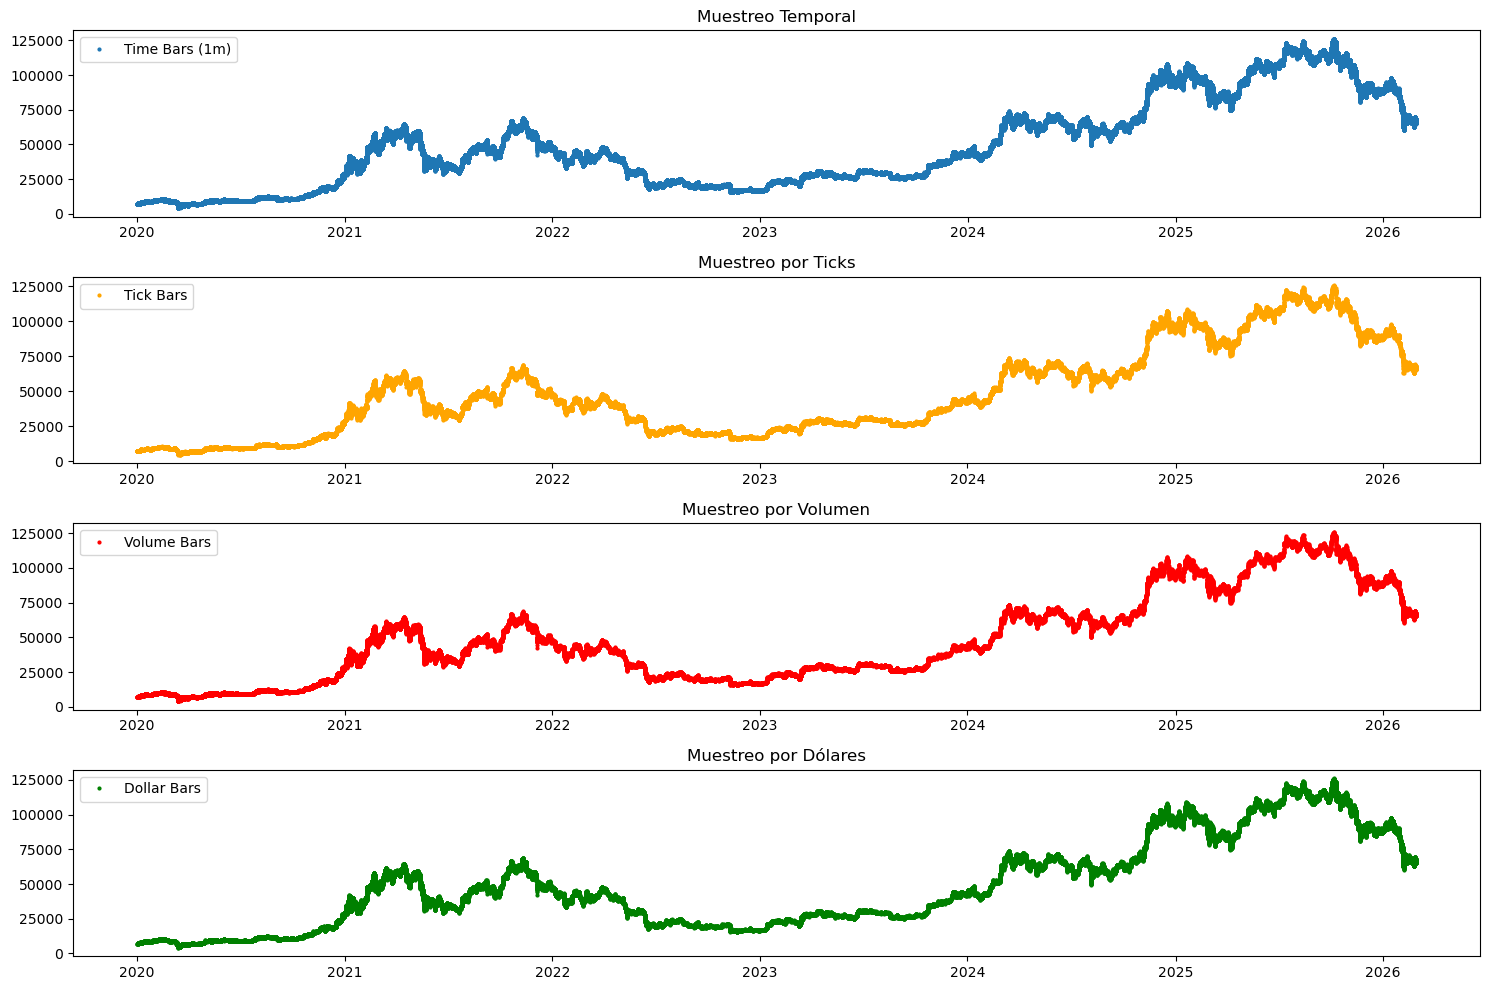

In [ ]:
# Gráfica de comparación
plt.figure(figsize=(15, 10))

plt.subplot(4, 1, 1)
plt.plot(df.index, df['close'], marker='o', ls='', markersize=2, label='Time Bars (1m)')
plt.title('Muestreo Temporal')
plt.legend(loc = 'upper left')

plt.subplot(4, 1, 2)
plt.plot(t_bars.index, t_bars['close'], marker='o', ls='', markersize=2, color='orange', label='Tick Bars')
plt.title('Muestreo por Ticks')
plt.legend(loc = 'upper left')

plt.subplot(4, 1, 3)
plt.plot(v_bars.index, v_bars['close'], marker='o', ls='', markersize=2, color='red', label='Volume Bars')
plt.title('Muestreo por Volumen')
plt.legend(loc = 'upper left')

plt.subplot(4, 1, 4)
plt.plot(d_bars.index, d_bars['close'], marker='o', ls='', markersize=2, color='green', label='Dollar Bars')
plt.title('Muestreo por Dólares')
plt.legend(loc = 'upper left')

plt.tight_layout()
plt.show()

Cómo resultado podemos ver que en los gráficos de líneas de la celda superior, se mantienen las tendencias de los precios a pesar de haber reducido enormemente el tamaño de la muestra.
1) El gráfico superior (**azul**) muestra los datos en función de su **Time bars**. Es decir, cada punto representa el estado del mercado. Entre cada punto hay un minuto de diferencia.
2) El segundo gráfico (**naranja**) muestra los datos en función de su **Tick bars**. Cada punto representa el momento en el que se ha producido cierto número de transacciones en el mercado, en este caso 80 operaciones.
3) El tercer gráfico (**rojo**) muestra los datos en función de su **Volume bars**. Cada punto representa el momento en el que se ha producido intercambios de cierta cantidad del activo en el mercado, en este caso 200 BTC.
4) El último gráfico (**verde**) muestra los datos en función de su **Dolar bars**. Cada punto representa el momento en el que se intercambia cierta cantidad de dinero en el mercado de un activo, en este caso 4.000.000$.

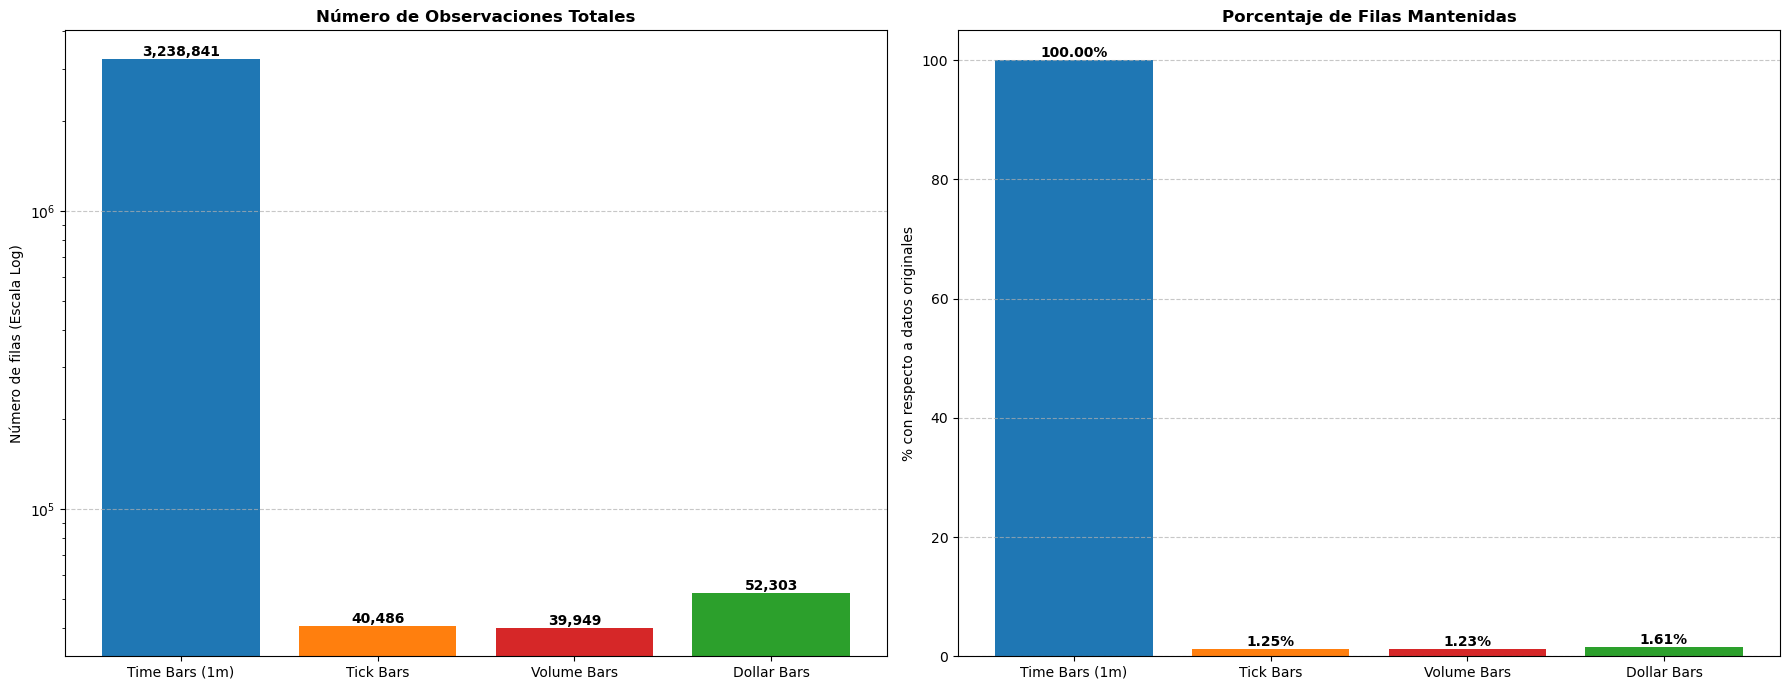

In [ ]:
# 1. Preparación de datos comunes
labels = ['Time Bars (1m)', 'Tick Bars', 'Volume Bars', 'Dollar Bars']
counts_abs = [len(df), len(t_bars), len(v_bars), len(d_bars)]
counts_pct = np.array(counts_abs) / len(df) * 100
colors = ['#1f77b4', '#ff7f0e', '#d62728', '#2ca02c']

# 2. Crear figura con dos subgráficos (1 fila, 2 columnas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# --- GRÁFICA 1: VALORES ABSOLUTOS ---
bars1 = ax1.bar(labels, counts_abs, color=colors)
ax1.set_title('Número de Observaciones Totales', fontweight='bold')
ax1.set_ylabel('Número de filas (Escala Log)')
ax1.set_yscale('log')  # Escala logarítmica para manejar la diferencia de magnitud
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Etiquetas de valor absoluto
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval, f'{int(yval):,}', 
             va='bottom', ha='center', fontweight='bold')

# --- GRÁFICA 2: PORCENTAJES ---
bars2 = ax2.bar(labels, counts_pct, color=colors)
ax2.set_title('Porcentaje de Filas Mantenidas', fontweight='bold')
ax2.set_ylabel('% con respecto a datos originales')
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# Etiquetas de porcentaje con 2 decimales
for bar in bars2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.2f}%', 
             va='bottom', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Como conclusión, hemos conseguido reducir enormemente el número de muestras que podríamos usar en nuestros futuros modelos. Sin embargo, debemos comprobar si, tal y como se indica en los estudios del Sr. López de Prado, estas reducciones de observaciones hacen que los retornos de estos datos filtrados tiendan a una distribución normal.

In [ ]:
# 1. Calcular log-retornos
returns_time = np.log(df['close']).diff().dropna()
returns_tick = np.log(t_bars['close']).diff().dropna()
returns_vol = np.log(v_bars['close']).diff().dropna()
returns_dollar = np.log(d_bars['close']).diff().dropna()

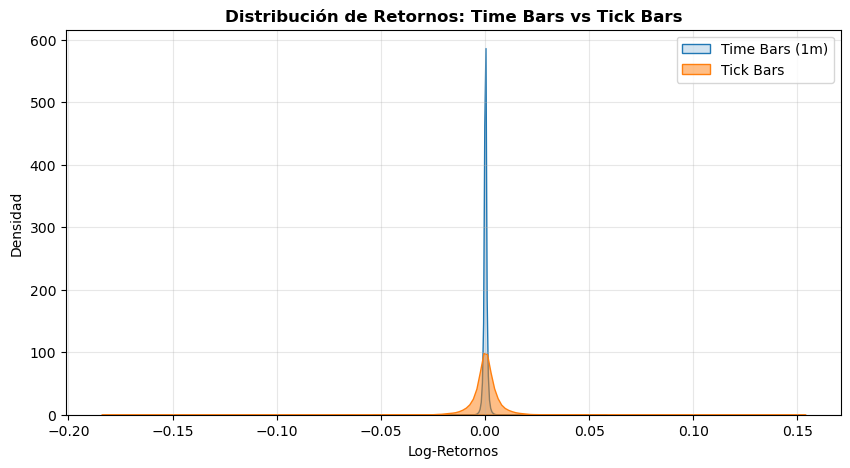

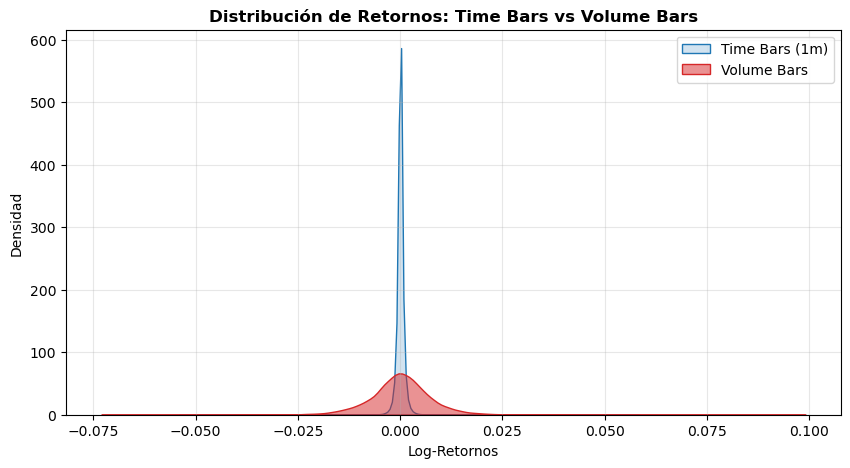

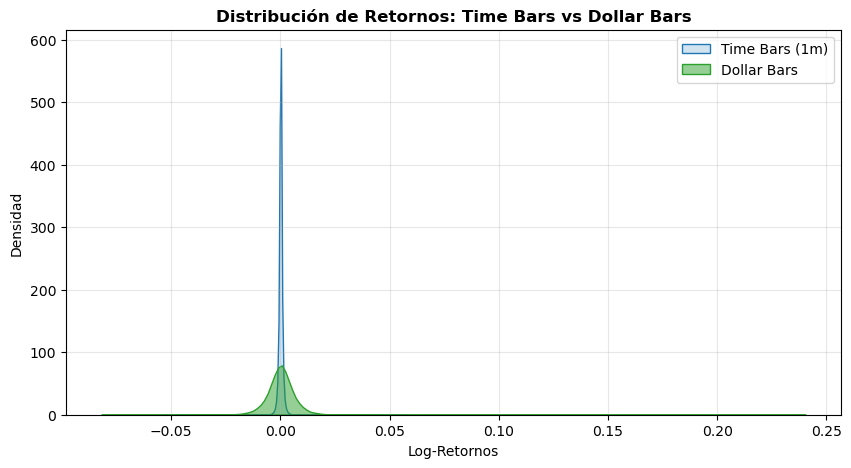

In [ ]:
comparaciones = [
    (returns_tick, 'Tick Bars', '#ff7f0e'),
    (returns_vol, 'Volume Bars', '#d62728'),
    (returns_dollar, 'Dollar Bars', '#2ca02c')
]

# 2. Generar los 3 gráficos independientes
for res_data, label, color in comparaciones:
    plt.figure(figsize=(10, 5))
    
    # Serie original (Time Bars)
    sns.kdeplot(returns_time, label='Time Bars (1m)', color='#1f77b4', fill=True, alpha=0.2)
    
    # Serie nueva (Tick/Vol/Dollar)
    sns.kdeplot(res_data, label=label, color=color, fill=True, alpha=0.5)
    
    plt.title(f'Distribución de Retornos: Time Bars vs {label}', fontweight='bold')
    plt.xlabel('Log-Retornos')
    plt.ylabel('Densidad')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

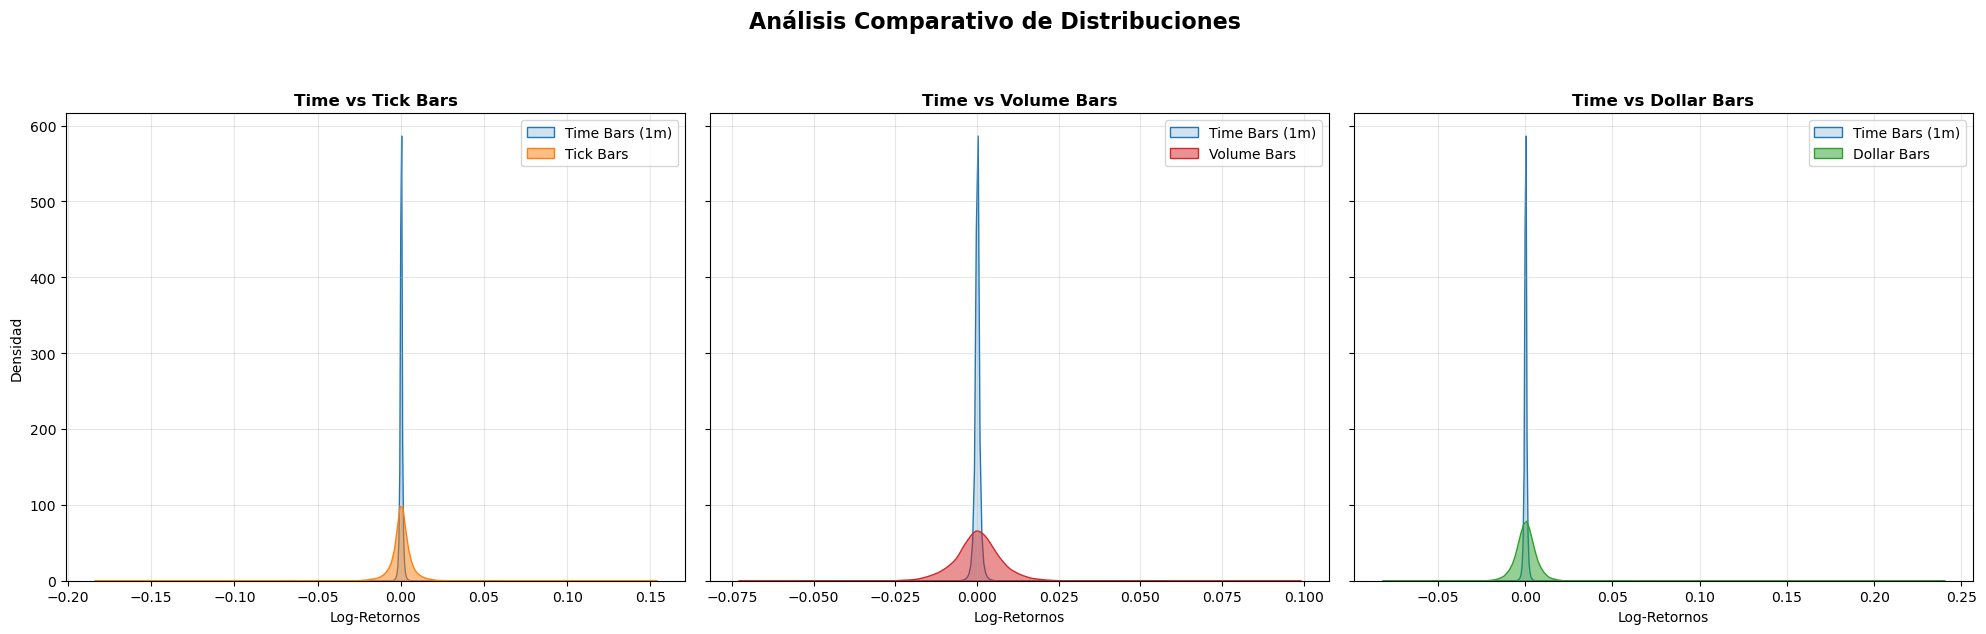

In [ ]:
comparaciones = [
    (returns_tick, 'Tick Bars', '#ff7f0e'),
    (returns_vol, 'Volume Bars', '#d62728'),
    (returns_dollar, 'Dollar Bars', '#2ca02c')
]

# 2. Generar una fila con 3 subgráficos
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

for i, (res_data, label, color) in enumerate(comparaciones):
    # Serie original (Time Bars) de fondo en cada gráfico
    sns.kdeplot(returns_time, ax=axes[i], label='Time Bars (1m)', color='#1f77b4', fill=True, alpha=0.2)
    
    # Serie nueva (Tick/Vol/Dollar)
    sns.kdeplot(res_data, ax=axes[i], label=label, color=color, fill=True, alpha=0.5)
    
    axes[i].set_title(f'Time vs {label}', fontweight='bold')
    axes[i].set_xlabel('Log-Retornos')
    axes[i].legend()
    axes[i].grid(alpha=0.3)

axes[0].set_ylabel('Densidad')
plt.suptitle('Análisis Comparativo de Distribuciones', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

A la vista de los histogramas de la celda superior donde se compara para cada tipo de bar su distribución de retornos con respecto a los datos totales, podemos apreciar que estos datos filtrados se parecen mucho más a los de una distribución normal. Para confirmarlo, debemos comprobar si pasan los principales test de normalidad.

In [ ]:
def analizar_normalidad(data, nombre_barra):
    # Calcular log-retornos y limpiar
    returns = np.log(data).diff().dropna()
    
    # 1. Test de D'Agostino-Pearson
    k2, p_value = stats.normaltest(returns)
    
    # 2. Métricas de forma (Asimetría y Curtosis)
    skewness = stats.skew(returns)
    excess_kurtosis = stats.kurtosis(returns) # Normal = 0
    
    return {
        'Barra': nombre_barra,
        'Estadístico K2': round(k2, 2),
        'p-valor': f"{p_value:.4e}",
        'Asimetría': round(skewness, 2),
        'Curtosis en exceso': round(excess_kurtosis, 2),
        '¿Es Normal? (alpha>=0.05)': 'Sí' if p_value > 0.05 else 'No'
    }

# Ejecutar para todos los tipos
resultados = [
    #analizar_normalidad(df['close'], 'Time Bars (1m)'),
    analizar_normalidad(t_bars['close'], 'Tick Bars'),
    analizar_normalidad(v_bars['close'], 'Volume Bars'),
    analizar_normalidad(d_bars['close'], 'Dollar Bars')
]

# Mostrar como tabla
df_stats = pd.DataFrame(resultados)
display(df_stats)

,Barra,Estadístico K2,p-valor,Asimetría,Curtosis en exceso,¿Es Normal? (alpha>=0.05)
0,Tick Bars,12949.28,0.0000e+00,-0.43,32.61,No
1,Volume Bars,3393.37,0.0000e+00,0.02,3.67,No
2,Dollar Bars,19718.63,0.0000e+00,0.73,37.64,No


In [ ]:
def analizar_series_avanzado(data, nombre_barra):
    returns = np.log(data).diff().dropna()
    
    # 1. Autocorrelación (Ljung-Box) - Lag 10
    # Hipótesis Nula: Los datos son ruido blanco (no autocorrelacionados)
    lb_test = acorr_ljungbox(returns, lags=[10])
    lb_pvalue = lb_test.lb_pvalue.values[0]
    
    # 2. Homocedasticidad (Test de Engle / ARCH)
    # Hipótesis Nula: No hay efectos ARCH (varianza constante)
    arch_test = het_arch(returns)
    arch_pvalue = arch_test[1]
    
    # 3. Volatilidad (Desviación Estándar) - Métrica de estabilidad
    volatilidad = returns.std()

    return {
        'Barra': nombre_barra,
        'Autocorr. (p-valor)': f"{lb_pvalue:.4e}",
        '¿Ruido Blanco?': 'Sí' if lb_pvalue > 0.05 else 'No',
        'Homocedast. (p-valor)': f"{arch_pvalue:.4e}",
        '¿Varianza Constante?': 'Sí' if arch_pvalue > 0.05 else 'No',
        'Volatilidad (std)': round(volatilidad, 6)
    }

# Ejecutar para todos
stats_avanzadas = [
    #analizar_series_avanzado(df['close'], 'Time Bars (1m)'),
    analizar_series_avanzado(t_bars['close'], 'Tick Bars'),
    analizar_series_avanzado(v_bars['close'], 'Volume Bars'),
    analizar_series_avanzado(d_bars['close'], 'Dollar Bars')
]

df_stats_av = pd.DataFrame(stats_avanzadas)
display(df_stats_av)

,Barra,Autocorr. (p-valor),¿Ruido Blanco?,Homocedast. (p-valor),¿Varianza Constante?,Volatilidad (std)
0,Tick Bars,2.1527e-16,No,0.0000e+00,No,0.007709
1,Volume Bars,3.0193e-16,No,0.0000e+00,No,0.007583
2,Dollar Bars,7.7521e-31,No,0.0000e+00,No,0.006650


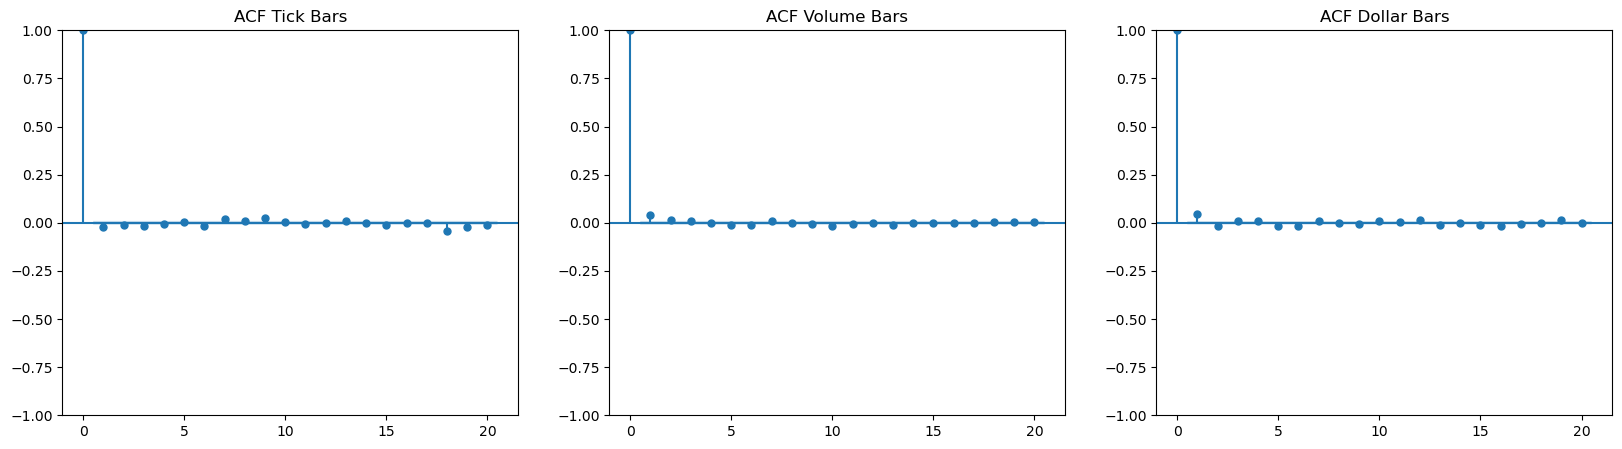

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=False)
series = [returns_tick, returns_vol, returns_dollar]
names = ['Tick', 'Volume', 'Dollar']

for i in range(len(series)):
    plot_acf(series[i], ax=axes[i], lags=20, title=f'ACF {names[i]} Bars')
    #axes[i].set_ylim(-0.1, 0.1) # Zoom para ver pequeñas correlaciones

plt.show()

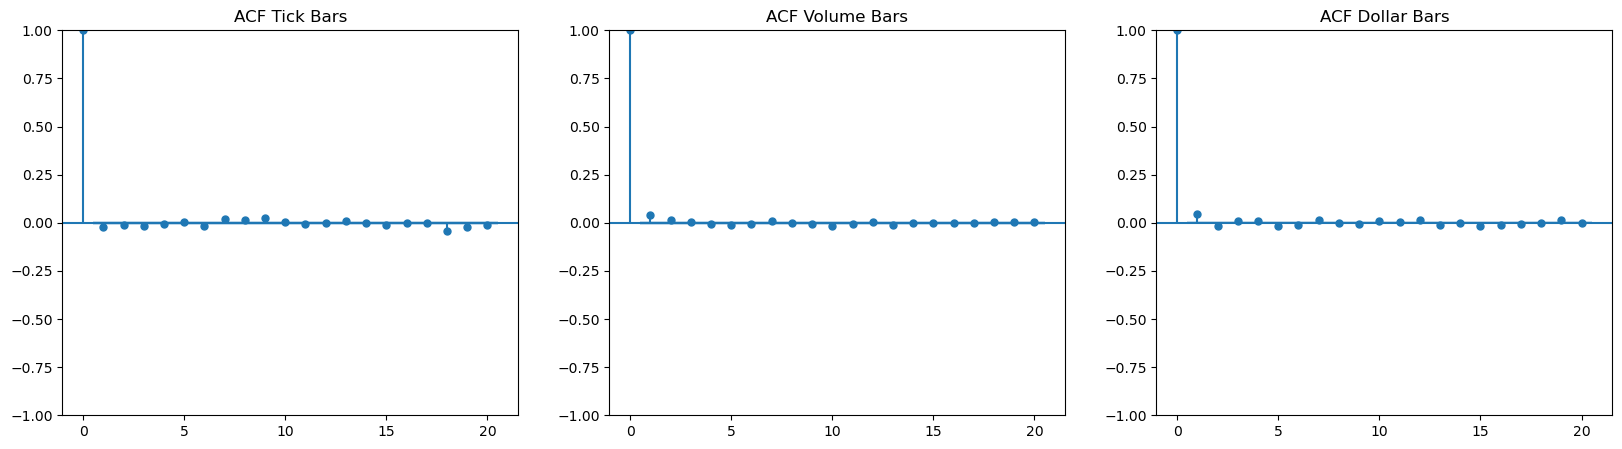

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=False)
series = [returns_tick, returns_vol, returns_dollar]
names = ['Tick', 'Volume', 'Dollar']

for i in range(len(series)):
    plot_pacf(series[i], ax=axes[i], lags=20, title=f'ACF {names[i]} Bars')
    #axes[i].set_ylim(-0.1, 0.1) # Zoom para ver pequeñas correlaciones

plt.show()

Sin embargo, como resultado de los test de normalidad, los retornos de los diferentes bars no es normal. La forma de la distribución se asemeja mucho más a la de la normal porque hemos eliminado un gran cantidad de retornos redundantes que se encontraban alrededor del cero, es decir, hemos eliminado ruido.

De acuerdo con los gráficos de correlaciones ACF, podemos apreciar que se puede asumir que no hay autocorrelación en ningún tipo de bar, es decir, no hay dependencias de las observaciones con observaciones pasadas.

## 2. Procesar los datos haciendo diferenciación fraccional con varios 'd'

In [ ]:
def get_Weights(d, size):
    w = [1.]
    for k in range(1, size):
        w_ = -w[-1]*((d-k+1)/k)
        w.append(w_)
    return np.array(w[::-1]).reshape(-1, 1)

def plotWeights(dRange, nPlots, size):
    w = pd.DataFrame()
    for d in np.linspace(dRange[0], dRange[1], nPlots):
        w_ = get_Weights(d, size)
        w_ = pd.DataFrame(w_, index = range(w_.shape[0])[::-1], columns = [f"{d:.2f}"])
        w = w.join(w_, how = 'outer')
    ax = w.plot()
    ax.legend(loc = 'upper right');plt.show()
    return

def fracDiff(series, d, threshold=0.01):
    """Versión optimizada de Diferenciación Fraccional para evitar errores de índices."""
    if isinstance(series, pd.Series):
        series = series.to_frame()
    
    # 1. Generar pesos
    w = get_Weights(d, series.shape[0])
    
    # 2. Punto de corte (skip)
    w_abs = np.cumsum(np.abs(w))
    w_abs /= w_abs[-1]
    skip = w_abs[w_abs > threshold].shape[0]
    
    df_result = {}
    for name in series.columns:
        seriesF = series[name].ffill().dropna()
        vals = seriesF.values
        res = {}
        
        for iloc in range(skip, vals.shape[0]):
            loc = seriesF.index[iloc]
            if not np.isfinite(vals[iloc]):
                continue
            
            # Slices de pesos y datos
            w_curr = w[-(iloc+1):]
            dat_curr = vals[:iloc+1]
            
            # CORRECCIÓN DEL ERROR: .item() convierte el resultado en un número simple
            res[loc] = np.dot(w_curr.T, dat_curr).item()
            
        df_result[name] = pd.Series(res)
    
    return pd.DataFrame(df_result)

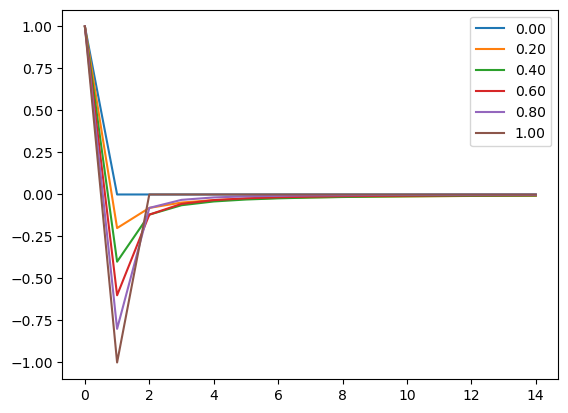

In [ ]:
plotWeights([0,1], 6, 15)

Tal y como se puede apreciar, la diferenciación fraccional otorga pesos a las observaciones pasadas.

Las principales conclusiones son:
- **Caso d = 0:** Solo se utiliza el dato actual. Mantenemos las tendencias de la variable pero nos alejamos del ruido blanco
- **Caso d = 1:** Se calcula un nuevo valor como la diferencia entre el actual y el inmediatamente anterior. Con esto eliminamos la tendencia y conseguimos un ruido blanco. Como se puede apreciar, solo tienen pesos el primer valor y el segundo valor y equivale a $y_t = (1-B)*x_t = x_t - x_{t-1}$
- **Caso d > 0 & d < 1:** Es un caso diferente a los dos anteriores. En este caso se dan pesos a las observaciones que son anteriores a la observación anterior. Como se puede apreciar los pesos van tendiendo a cero, por lo que las observaciones más alejadas van teniendo menos peso en el cálculo del valor

In [ ]:
def analizar_varios_d(series, d_values, threshold=0.01):
    """
    Realiza la diferenciación fraccional para varios valores de d,
    calcula su estacionariedad (ADF) y grafica los resultados en 2 columnas.
    """
    if isinstance(series, pd.Series):
        series = series.to_frame()
        
    col_name = series.columns[0]
    n_plots = len(d_values)
    
    # Calculamos el número de filas necesarias para 2 columnas
    n_cols = 2
    n_rows = int(np.ceil(n_plots / n_cols))
    
    # Creamos la figura con la nueva disposición
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
    
    # Aplanamos el array de axes para iterar fácilmente (pasa de 2D a 1D)
    axes_flat = axes.flatten()
    
    resultados_stats = []

    for i, d in enumerate(d_values):
        # 1. Ejecutar Diferenciación Fraccional
        df_frac = fracDiff(series[[col_name]], d, threshold=threshold)
        
        # 2. Calcular Test de Estacionariedad (ADF)
        serie_limpia = df_frac[col_name].dropna()
        adf_stat, p_val, _, _, _, _ = adfuller(serie_limpia)
        
        # 3. Calcular Correlación
        df_corr = pd.concat([series[col_name], df_frac[col_name]], axis=1).dropna()
        corr = df_corr.iloc[:, 0].corr(df_corr.iloc[:, 1])
        
        # 4. Graficar en el eje correspondiente
        ax = axes_flat[i]
        ax.plot(df_frac[col_name], color=plt.cm.viridis(i / n_plots), label=f'd={d:.2f}')
        ax.set_title(f"d={d:.2f} | ADF p-val: {p_val:.4f} | Corr: {corr:.4f}", fontweight='bold')
        ax.legend(loc='upper left')
        ax.grid(alpha=0.3)
        
        resultados_stats.append({
            'd': round(d, 2),
            'Dickey-Fuller stat': adf_stat,
            'p-value': p_val,
            'Correlación': corr,
            'Estacionaria': 'Sí' if p_val < 0.05 else 'No'
        })

    # Si el número de gráficos es impar, eliminamos el último eje vacío
    if n_plots % 2 != 0:
        fig.delaxes(axes_flat[-1])

    plt.tight_layout()
    plt.show()
    
    return pd.DataFrame(resultados_stats)

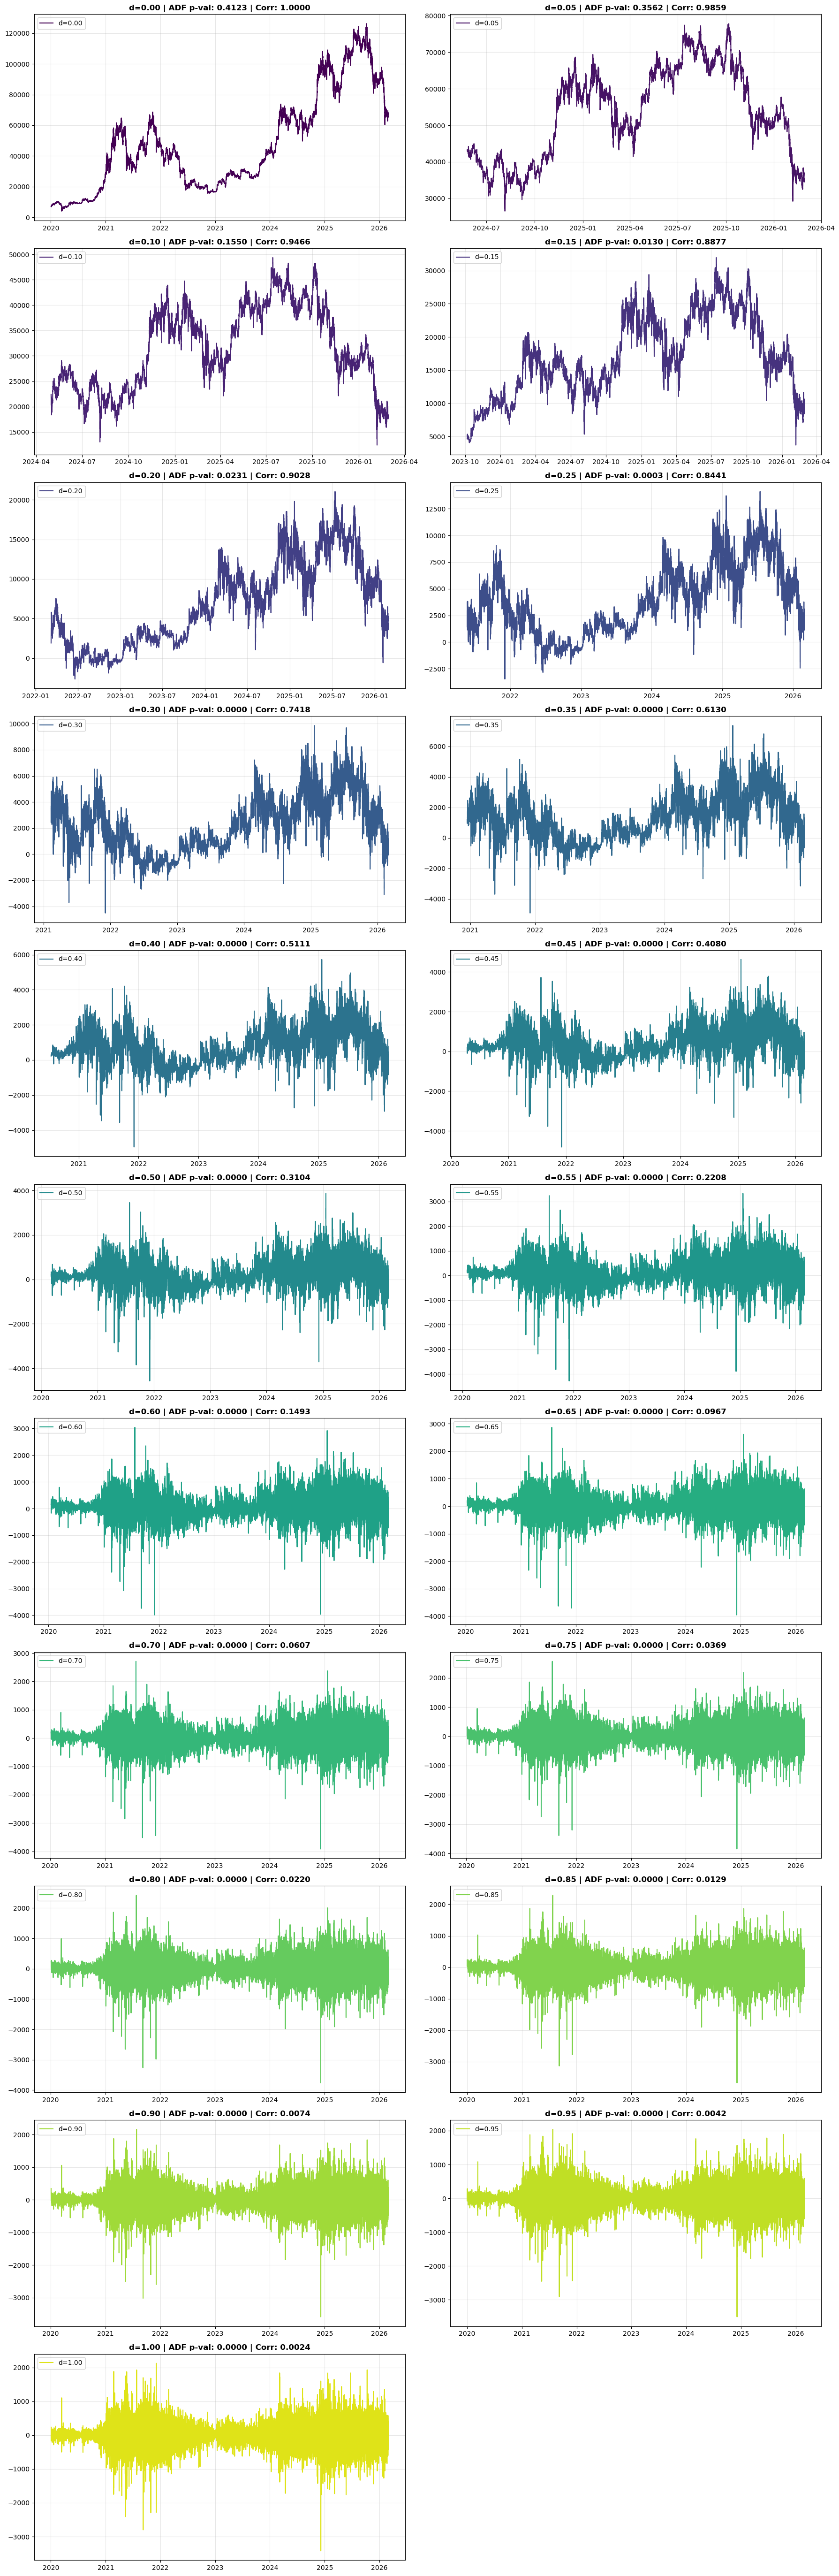

,d,Dickey-Fuller stat,p-value,Correlación,Estacionaria
0,0.00,-1.736717,4.123007e-01,1.000000,No
1,0.05,-1.849398,3.562273e-01,0.985927,No
2,0.10,-2.354612,1.549585e-01,0.946589,No
3,0.15,-3.344545,1.300099e-02,0.887745,Sí
4,0.20,-3.149046,2.313013e-02,0.902754,Sí
5,0.25,-4.393596,3.046750e-04,0.844112,Sí
6,0.30,-5.362991,4.049278e-06,0.741845,Sí
7,0.35,-6.873795,1.492334e-09,0.612973,Sí
8,0.40,-8.423042,1.960026e-13,0.511093,Sí
9,0.45,-10.182421,6.641160e-18,0.408024,Sí


In [ ]:
# --- EJECUCIÓN ---
# Probamos con tus Dollar Bars
d_vector = np.linspace(0,1,21)
#d_vector = [1]
df_comparativa = analizar_varios_d(d_bars[['close']], d_vector)

# Mostrar la tabla de resultados para elegir el 'd' óptimo
display(df_comparativa)

**Como conclusión**:

Podemos apreciar que el valor optimo de diferenciación $d$ es 0.2 porque:
- Es el valor d que **mantiene una mayor correlación** con los datos originales de los dollar bars.
- Es estacionaria según el test de **Dickey-Fuller**.

## 3. Limpieza de matrices de covarianzas ruidosa

In [ ]:
# ==========================================
# BLOQUE 1: Funciones Auxiliares (López de Prado)
# ==========================================

def get_pca(matrix):
    """Obtiene autovalores y autovectores ordenados de forma descendente."""
    e_val, e_vec = np.linalg.eigh(matrix)
    indices = e_val.argsort()[::-1] # Orden descendente
    e_val, e_vec = e_val[indices], e_vec[:, indices]
    e_val = np.diagflat(e_val)
    return e_val, e_vec

def denoise_matrix_mp(corr_matrix, T, N):
    """
    Limpia la matriz de correlación eliminando el ruido usando el método
    'Constant Residual' de Marchenko-Pastur.
    """
    if isinstance(corr_matrix, pd.DataFrame):
        corr_matrix = corr_matrix.values
        
    q = T / N
    e_val, e_vec = get_pca(corr_matrix)
    e_val_diag = np.diag(e_val)
    
    # 1. Encontrar el límite de Marchenko-Pastur (sigma^2=1 para correlación)
    sigma_sq = 1.0 
    e_max = sigma_sq * (1 + (1./q)**0.5)**2
    
    # 2. Identificar autovalores de señal vs ruido
    n_facts = e_val_diag[e_val_diag > e_max].shape[0]
    
    # 3. Aplicar "Constant Residual": Sustituir ruidosos por su promedio
    e_val_denoised = e_val_diag.copy()
    media_ruido = e_val_diag[n_facts:].sum() / float(e_val_diag.shape[0] - n_facts)
    e_val_denoised[n_facts:] = media_ruido
    
    # 4. Reconstruir la matriz de correlación
    corr_denoised = np.dot(e_vec, np.dot(np.diag(e_val_denoised), e_vec.T))
    
    # 5. Re-escalar para asegurar que la diagonal vuelva a ser 1s
    d = np.diag(corr_denoised)
    std = np.sqrt(d)
    corr_denoised /= np.outer(std, std)
    
    return corr_denoised, e_max, e_val_diag

In [ ]:
# ==========================================
# BLOQUE 2: Ejecución del Ejercicio 3
# ==========================================

print("--- PASO 1: Calcular Retornos Logarítmicos ---")
# Usamos retornos logarítmicos para estacionarizar y normalizar
df_returns = np.log(df_ej3).diff().dropna()
T, N = df_returns.shape
print(f"Dimensiones de los retornos: {T} filas (observaciones), {N} columnas (activos)")

print("\n--- PASO 2: Calcular Matrices Originales ---")
cov_ruidosa = df_returns.cov()
corr_ruidosa = df_returns.corr()
# Guardamos las desviaciones típicas (volatilidad) originales
std_originales = np.sqrt(np.diag(cov_ruidosa))

print("\n--- PASO 3: Limpieza de la Correlación (Denoising) ---")
# Aplicamos la limpieza a la matriz de correlación
corr_limpia_arr, e_max, e_val_orig_vector = denoise_matrix_mp(corr_ruidosa, T, N)
corr_limpia_df = pd.DataFrame(corr_limpia_arr, index=corr_ruidosa.index, columns=corr_ruidosa.columns)

print("\n--- PASO 4: Reconstruir la Covarianza Limpia ---")
# Re-escalamos la correlación limpia usando las volatilidades originales
# Cov = diag(std) * Corr * diag(std)
cov_limpia_arr = np.outer(std_originales, std_originales) * corr_limpia_arr
cov_limpia_df = pd.DataFrame(cov_limpia_arr, index=cov_ruidosa.index, columns=cov_ruidosa.columns)

print("\n--- PROCESO COMPLETADO ---")
print("Matrices calculadas: 'cov_limpia_df' y 'corr_limpia_df'")

--- PASO 1: Calcular Retornos Logarítmicos ---
Dimensiones de los retornos: 581488 filas (observaciones), 10 columnas (activos)

--- PASO 2: Calcular Matrices Originales ---

--- PASO 3: Limpieza de la Correlación (Denoising) ---

--- PASO 4: Reconstruir la Covarianza Limpia ---

--- PROCESO COMPLETADO ---
Matrices calculadas: 'cov_limpia_df' y 'corr_limpia_df'



--- PASO 5: Generar Gráficos ---


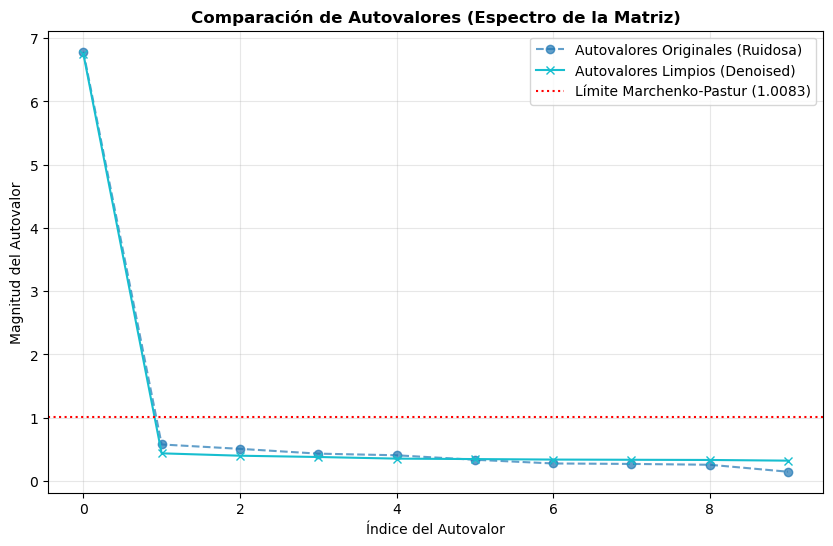

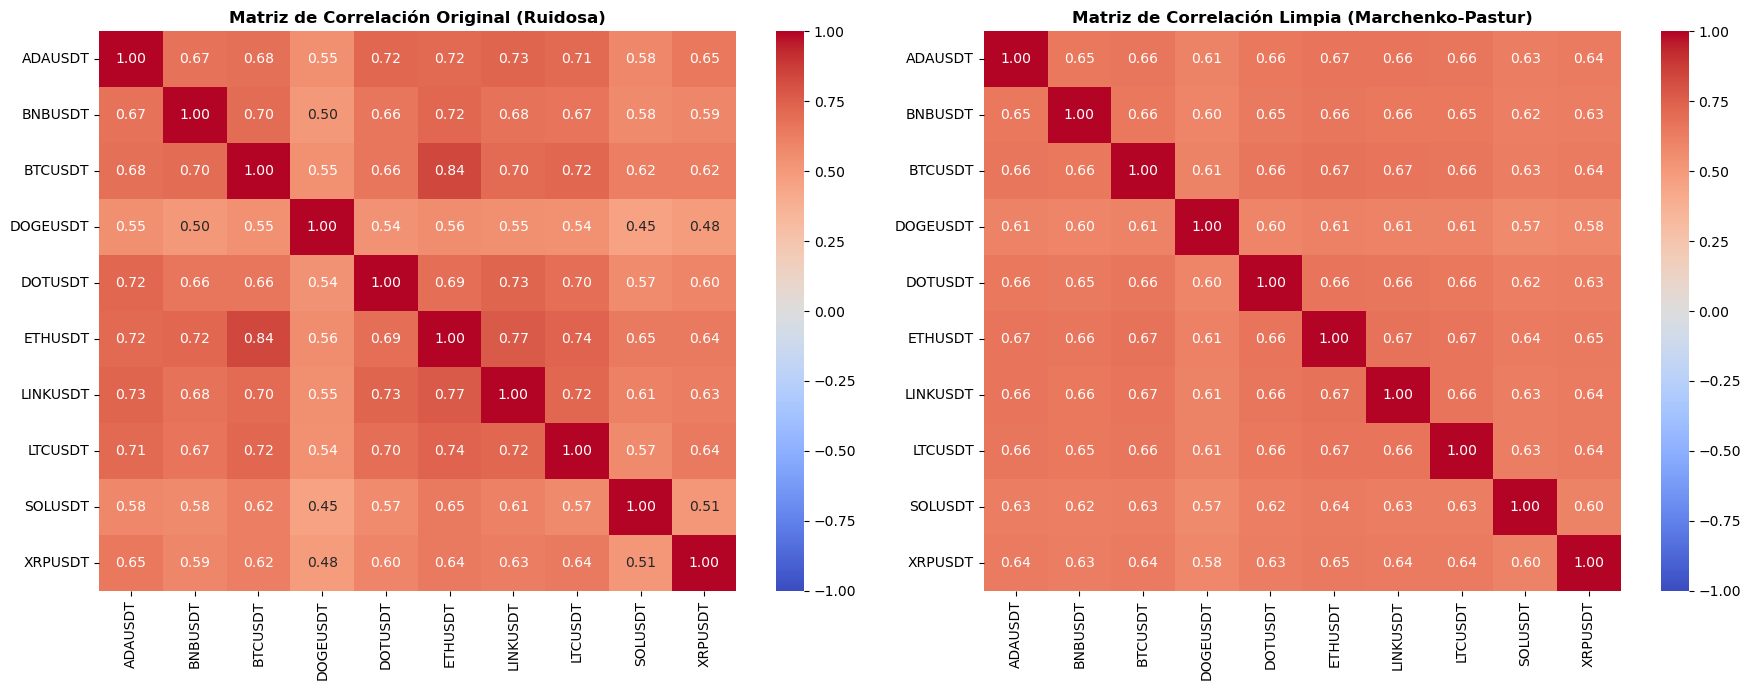

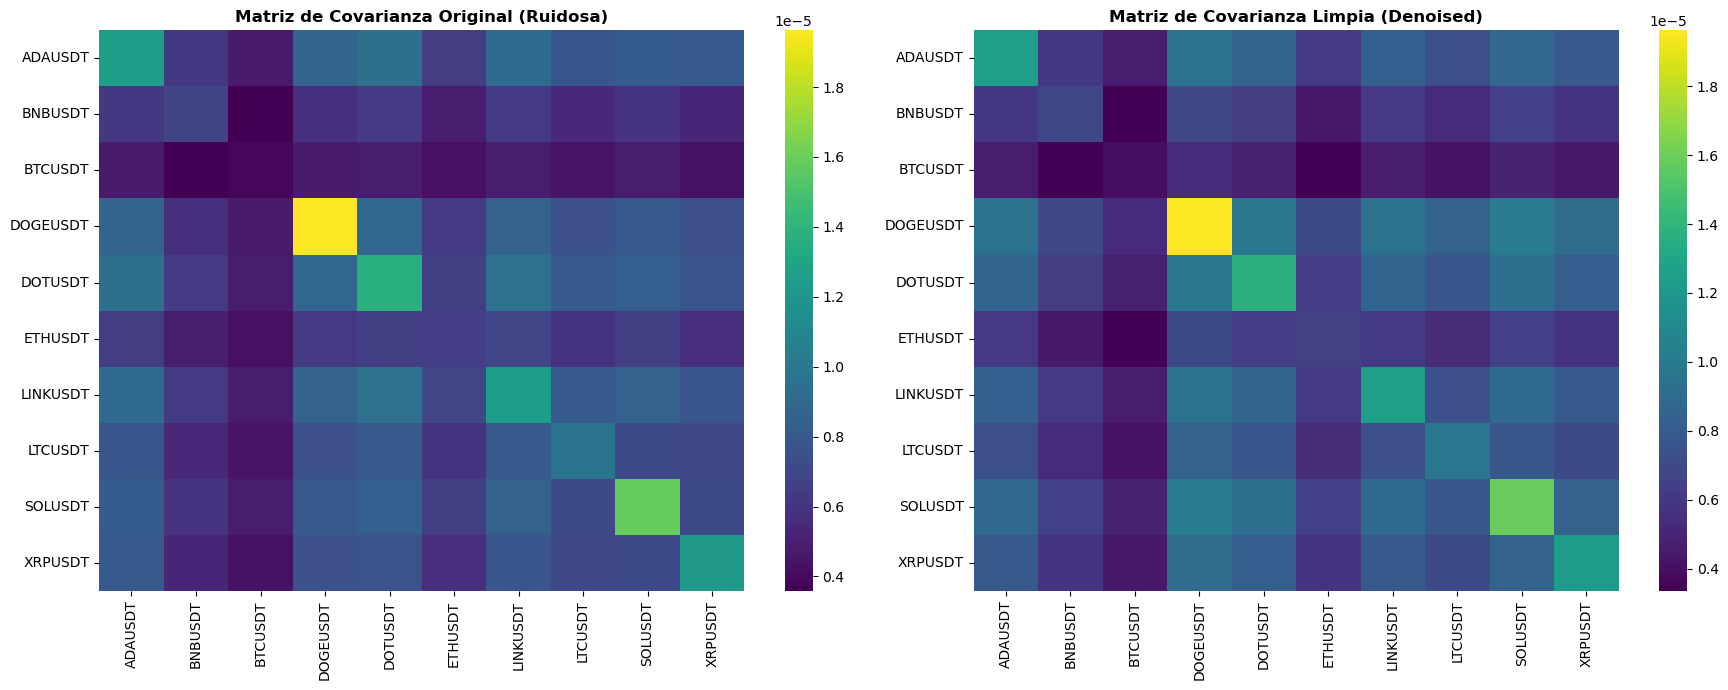


Número de Condición Original: 100.19
Número de Condición Limpia:   55.17
Mejora de estabilidad numérica: 81.61%


In [ ]:
# ==========================================
# BLOQUE 3: Gráficos y Visualización
# ==========================================

print("\n--- PASO 5: Generar Gráficos ---")

# Gráfico 1: Espectro de Autovalores (Scree Plot)
# Extraemos los autovalores y aseguramos que sean vectores 1D ordenados
e_val_orig_vector_sorted = np.sort(e_val_orig_vector)[::-1]
# Para la matriz limpia, recalculamos para asegurar que el vector sea 1D y esté ordenado
e_val_limp_raw = np.linalg.eigvals(corr_limpia_arr)
e_val_limpia_vector = np.sort(e_val_limp_raw)[::-1]

plt.figure(figsize=(10, 6))

# Al pasar vectores 1D, Matplotlib solo genera UNA entrada en la leyenda por cada .plot()
plt.plot(e_val_orig_vector_sorted, label='Autovalores Originales (Ruidosa)', 
         marker='o', ls='--', color='tab:blue', alpha=0.7)

plt.plot(e_val_limpia_vector, label='Autovalores Limpios (Denoised)', 
         marker='x', ls='-', color='tab:cyan')

plt.axhline(y=e_max, color='r', linestyle=':', label=f'Límite Marchenko-Pastur ({e_max:.4f})')

plt.title("Comparación de Autovalores (Espectro de la Matriz)", fontweight='bold')
plt.ylabel("Magnitud del Autovalor")
plt.xlabel("Índice del Autovalor")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Gráfico 2: Heatmaps Comparativos de Correlación
fig, ax = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(corr_ruidosa, ax=ax[0], annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
ax[0].set_title("Matriz de Correlación Original (Ruidosa)", fontweight='bold')

sns.heatmap(corr_limpia_df, ax=ax[1], annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
ax[1].set_title("Matriz de Correlación Limpia (Marchenko-Pastur)", fontweight='bold')
plt.tight_layout()
plt.show()

# Gráfico 3: Heatmaps Comparativos de COVARIANZA
fig, ax = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(cov_ruidosa, ax=ax[0], annot=False, cmap='viridis')
ax[0].set_title("Matriz de Covarianza Original (Ruidosa)", fontweight='bold')

sns.heatmap(cov_limpia_df, ax=ax[1], annot=False, cmap='viridis')
ax[1].set_title("Matriz de Covarianza Limpia (Denoised)", fontweight='bold')
plt.tight_layout()
plt.show()

# Opcional: Dato numérico de mejora de estabilidad
cond_orig = np.linalg.cond(cov_ruidosa)
cond_limpia = np.linalg.cond(cov_limpia_df)
print(f"\nNúmero de Condición Original: {cond_orig:.2f}")
print(f"Número de Condición Limpia:   {cond_limpia:.2f}")
print(f"Mejora de estabilidad numérica: {((cond_orig/cond_limpia)-1)*100:.2f}%")

En este caso, hemos trabajado con datos de 10 criptomonedas desde 2020 hasta febrero de 2026. Los datos tienen una temporalidad de cinco minutos.

Gracias a descomposición de la matriz de retornos a través del análisis de componentes principales, obtenemos sus valores y vectores propios. El umbral a partir del cual consideraremos un valor propio como significativo e informativo es aquel que sea superior al **límite de Marchenko-Pastur**. En este caso solo es la primera componente principal, por lo que el resto de componentes principales se considera ruido.

Esta primera componente principal significativa esta relacionada con el comportamiento del mercado ya que en general, las 10 criptomonedas están altamente correlacionadas. El resto de componentes principales, al considerarse ruido y ser indistinguibles al azar se homogeneizan. Este proceso de homogeneización implica que cada uno de los nuevos valores propios no significativos serán idénticos y surge de la media de los valores propios asociados a estos componentes.

La nueva matriz de correlaciones limpia se obtiene como el producto matricial entre la nueva matriz diagonal de valores propios multiplicado por la matriz de vectores propios y por la nueva matriz diagonal de valores propios traspuesto. Finalmente, para obtener la matriz de covarianzas limpia, se multiplica la matriz de correlaciones limpia por cada par de desviaciones típicas de cada criptomoneda.

Gracias a este ajuste se puede apreciar en los gráficos de correlaciones y covarianzas que se normalizan y estabilizan las relaciones entre criptomonedas. Eliminando el efecto del ruido y de las correlaciones espurias.

Al aplicar el denoising, hemos preservado este componente principal y neutralizado el ruido restante, logrando una mejora de la estabilidad numérica del 81.61%. Esto resulta en una matriz de covarianza mucho más robusta y menos propensa a errores de sobreajuste (overfitting) para futuros modelos de predicción.

## 4. Etiquetar datos usando método de la triple barrera con varios threshold

El método de la triple barrera consiste en que partiendo de un dato incial, en un instante temporal la señal será dependiendo de:
- **Supera a la barrera superior**: Es una señal de compra, el precio sigue una tendencia alcista.
- **Está por debajo de la barrera inferior**: Es una señal de venta, el precio sigue una tendencia bajista.
- **Supera la barrera vertical sin haber superado la barrera superior ni la inferior**: Durante el periodo de análisis, el precio se ha mantenido dentro del intervalo. No hay una señal, por lo que habría que mantener la posición.

In [ ]:
# ========================================================
# 1. FUNCIONES CORE (López de Prado - Triple Barrera)
# ========================================================

def get_daily_vol(close, span0=100):
    """Calcula la volatilidad suavizada para el ancho de las barreras."""
    df0 = close.index.searchsorted(close.index - pd.Timedelta(days=1))
    df0 = df0[df0 > 0]
    df0 = pd.Series(close.index[df0 - 1], index=close.index[close.shape[0] - df0.shape[0]:])
    df0 = close.loc[df0.index] / close.loc[df0.values].values - 1 
    df0 = df0.ewm(span=span0).std()
    return df0

def apply_pt_sl_on_t1(close, events, pt_sl):
    """
    Encuentra qué barrera se toca primero (PT, SL o Tiempo).
    Versión robusta con búsqueda de índice por proximidad.
    """
    out = events[['t1']].copy(deep=True)
    
    pt = pt_sl[0] * events['trgt'] if pt_sl[0] > 0 else pd.Series(index=events.index)
    sl = -pt_sl[1] * events['trgt'] if pt_sl[1] > 0 else pd.Series(index=events.index)

    for loc, t1 in events['t1'].fillna(close.index[-1]).items():
        df0 = close[loc:t1]
        # Búsqueda segura del precio inicial si el timestamp exacto no existe
        idx_start = close.index.get_indexer([loc], method='pad')[0]
        close_start = close.iloc[idx_start]
        
        returns = (df0 / close_start - 1) * events.at[loc, 'side']
        
        out.loc[loc, 'sl'] = returns[returns < sl[loc]].index.min()
        out.loc[loc, 'pt'] = returns[returns > pt[loc]].index.min()
    return out

def get_bins(triple_barrier_events, close):
    """Asigna la etiqueta final con manejo estricto de duplicados."""
    events_ = triple_barrier_events.dropna(subset=['t1'])
    out = pd.DataFrame(index=events_.index)
    
    for i in events_.index:
        # Forzamos a obtener un solo valor aunque haya duplicados en el índice
        pt = events_.loc[i, 'pt']
        sl = events_.loc[i, 'sl']
        t1 = events_.loc[i, 't1']
        
        # Si loc devuelve una Serie por duplicados, tomamos el primer elemento
        pt = pt.iloc[0] if isinstance(pt, pd.Series) else pt
        sl = sl.iloc[0] if isinstance(sl, pd.Series) else sl
        t1 = t1.iloc[0] if isinstance(t1, pd.Series) else t1
        
        timestamps = []
        if pd.notna(pt): timestamps.append(pt)
        if pd.notna(sl): timestamps.append(sl)
        if pd.notna(t1): timestamps.append(t1)
        
        if not timestamps: continue
            
        first_touch = min(timestamps)
        
        if first_touch == sl: out.loc[i, 'bin'] = -1
        elif first_touch == pt: out.loc[i, 'bin'] = 1
        else: out.loc[i, 'bin'] = 0
            
    return out

In [ ]:
# ========================================================
# 2. PREPARACIÓN DE DATOS Y EJECUCIÓN
# ========================================================

# A. Recorte de datos (Últimos 2 años para relevancia y velocidad)
fecha_limite = d_bars.index.max() - pd.Timedelta(days=365*2)
df_trim = d_bars[d_bars.index >= fecha_limite].copy()
close_btc = df_trim['close']

# B. Configuración de parámetros
vol = get_daily_vol(close_btc)
t_events = close_btc.index # Evaluamos cada minuto (o podrías filtrar por CUSUM)

# C. Definir horizonte temporal (t1 = 1 día)
t1_idx = close_btc.index.searchsorted(t_events + pd.Timedelta(days=1))
t1_idx = t1_idx[t1_idx < close_btc.shape[0]]
t1 = pd.Series(close_btc.index[t1_idx], index=t_events[:len(t1_idx)])

# D. Crear eventos base
events = pd.concat({'t1': t1, 'trgt': vol}, axis=1).dropna()
events['side'] = 1 # Asumimos posición larga para el etiquetado

[1/3] Procesando Etiquetas para PT:1 | SL:1...


C:\Users\mateo\AppData\Local\Temp\ipykernel_21128\347919347.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels([label_map.get(x, x) for x in counts.index], fontsize=10, fontweight='bold')


[2/3] Procesando Etiquetas para PT:2 | SL:1...


C:\Users\mateo\AppData\Local\Temp\ipykernel_21128\347919347.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels([label_map.get(x, x) for x in counts.index], fontsize=10, fontweight='bold')


[3/3] Procesando Etiquetas para PT:1 | SL:2...


C:\Users\mateo\AppData\Local\Temp\ipykernel_21128\347919347.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels([label_map.get(x, x) for x in counts.index], fontsize=10, fontweight='bold')


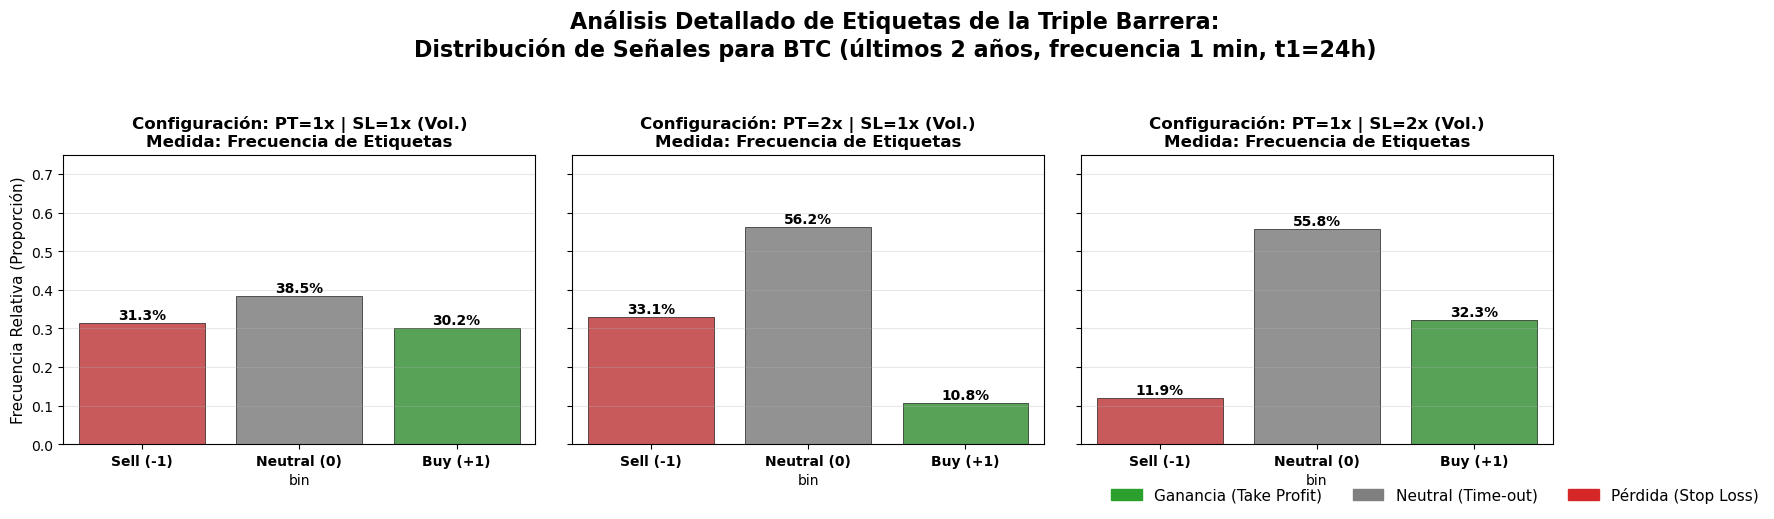

In [ ]:
# ========================================================
# 3. PROCESAMIENTO DE VARIOS THRESHOLDS Y GRÁFICOS
# ========================================================

# 1. Parámetros y Configuración Estética
thresholds = [[1, 1], [2, 1], [1, 2]]
results = {}

# Definición de colores: Rojo (Venta), Gris (Neutral), Verde (Compra)
# Incluimos claves en formato float y int para evitar el ValueError de Seaborn
palette_map = {
    -1: 'tab:red', 0: 'tab:gray', 1: 'tab:green',
    -1.0: 'tab:red', 0.0: 'tab:gray', 1.0: 'tab:green'
}

# Mapeo de texto para el eje X
label_map = {-1: 'Sell (-1)', 0: 'Neutral (0)', 1: 'Buy (+1)'}

# 2. Creación del Lienzo (Subplots)
fig, axes = plt.subplots(1, len(thresholds), figsize=(18, 6), sharey=True)

# Leyenda global personalizada
red_patch = mpatches.Patch(color='tab:red', label='Pérdida (Stop Loss)')
gray_patch = mpatches.Patch(color='tab:gray', label='Neutral (Time-out)')
green_patch = mpatches.Patch(color='tab:green', label='Ganancia (Take Profit)')

for i, pt_sl in enumerate(thresholds):
    print(f"[{i+1}/{len(thresholds)}] Procesando Etiquetas para PT:{pt_sl[0]} | SL:{pt_sl[1]}...")
    
    # --- CÁLCULOS TÉCNICOS ---
    # a. Tiempos de toque
    barrier_touches = apply_pt_sl_on_t1(close_btc, events, pt_sl)
    # b. Concatenación segura
    tb_events = pd.concat([events, barrier_touches], axis=1)
    tb_events = tb_events.loc[:, ~tb_events.columns.duplicated()]
    # c. Etiquetas finales
    labels = get_bins(tb_events, close_btc)
    # d. Métricas de Distribución (Forzamos índice a entero para evitar errores de claves)
    counts = labels['bin'].value_counts(normalize=True).sort_index()
    counts.index = counts.index.astype(int) 
    # --------------------------
    
    results[f"PT{pt_sl[0]}_SL{pt_sl[1]}"] = labels
    
    # 4. GRÁFICO (Histograma de Distribución de Clases)
    # Pasamos el palette_map directamente asegurando que las claves coincidan
    sns.barplot(x=counts.index, y=counts.values, ax=axes[i], 
                palette=palette_map,
                hue=counts.index, legend=False, # Hue ayuda a mapear correctamente los colores
                edgecolor='black', lw=0.5, alpha=0.85)
    
    # 5. Configuración de Ejes y Títulos
    axes[i].set_title(f"Configuración: PT={pt_sl[0]}x | SL={pt_sl[1]}x (Vol.)\nMedida: Frecuencia de Etiquetas", 
                      fontweight='bold', fontsize=12)
    
    axes[i].set_ylabel("Frecuencia Relativa (Proporción)", fontsize=11)
    
    # Mapeo de etiquetas del eje X basado en los valores presentes
    axes[i].set_xticklabels([label_map.get(x, x) for x in counts.index], fontsize=10, fontweight='bold')
    
    # Etiquetas de porcentaje sobre las barras
    for p in axes[i].patches:
        height = p.get_height()
        if height > 0: # Solo poner texto si hay barra
            axes[i].text(p.get_x()+p.get_width()/2.,
                        height + 0.01,
                        f'{height:.1%}',
                        ha="center", fontsize=10, fontweight='bold')
                    
    axes[i].grid(axis='y', alpha=0.3)
    axes[i].set_ylim(0, 0.75) 

# 6. Título Global y Leyenda
plt.suptitle("Análisis Detallado de Etiquetas de la Triple Barrera:\nDistribución de Señales para BTC (últimos 2 años, frecuencia 1 min, t1=24h)", 
              fontsize=16, fontweight='bold', y=0.98)

plt.legend(handles=[green_patch, gray_patch, red_patch], 
           loc='lower center', bbox_to_anchor=(0.75, -0.25), 
           ncol=3, fontsize=11, frameon=False)

plt.tight_layout(rect=[0, 0.05, 1, 0.94])
plt.show()

Se calcula una ventana temporal de 24 horas para todos los instantes temporales desde los últimos años. Para cada uno de ellos se considera si ha superado alguna de las barreras (superior, inferior y vertical).

Se han probado una serie de parámetros para simular diferentes condiciones de umbrales que marquen las señales de compra y venta. Los resultados son los siguientes:
- **Estrategia equilibrada**: los límites de las barreras superiores e inferiores son de la misma proporción. Se aprecia que la proporción de señales de compra y venta es muy similar, siendo algo mayor las de ventas. La mayoría de días se apuesta por mantener la orden activa. 
- **Estrategia con un umbral de compra grande**: Consideramos que la señal para comprar debe ser el doble que la de venta. Es decir, compramos ante movimientos alcistas mucho más agresivos.
- **Estrategia con un umbral de venta grande**: Consideramos que la señal para vender debe ser el doble que la de compra. Es decir, vendemos ante movimientos bajista mucho más profundos. Tenemos una tolerancia al riesgo alta

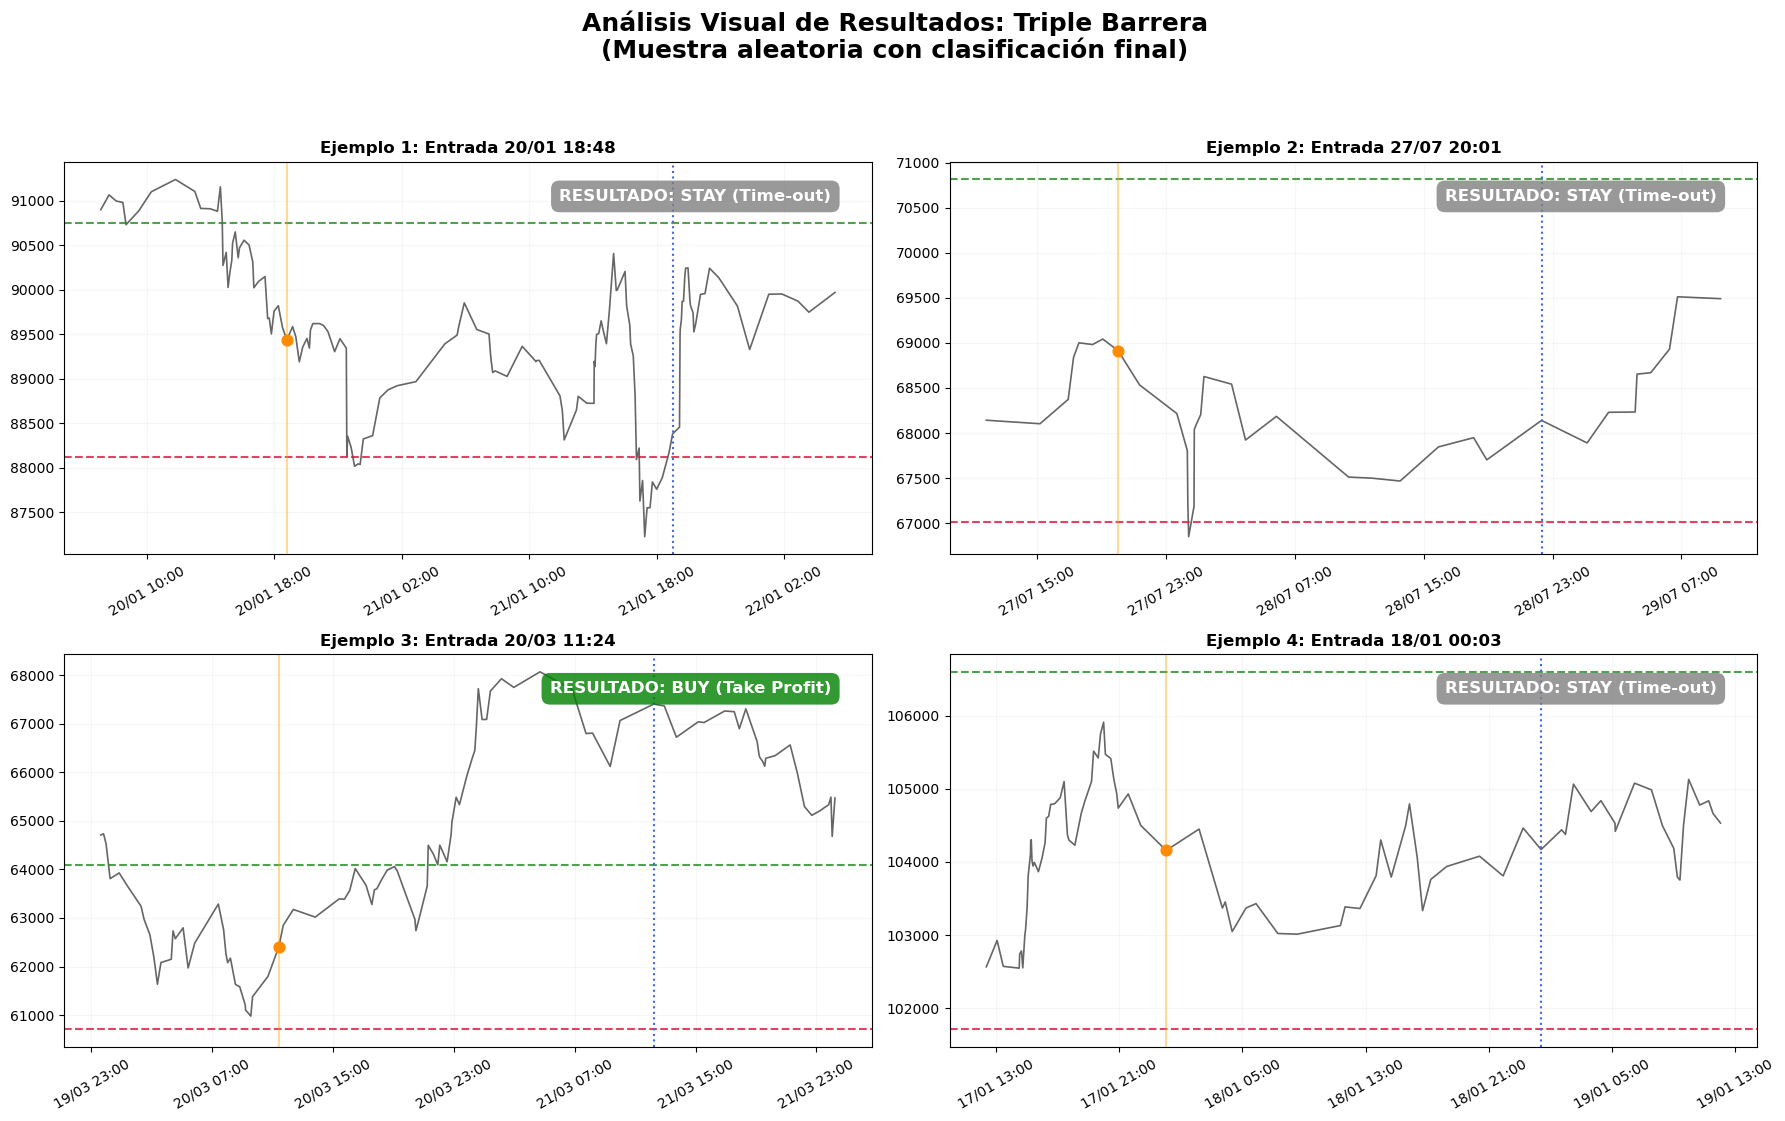

In [ ]:
# 1. Seleccionar 4 instantes aleatorios
random.seed(42) 
random_indices = random.sample(range(len(events)), 4)
selected_events = events.index[random_indices]

# 2. Configuración de la figura 2x2
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, sample_idx in enumerate(selected_events):
    # a. Obtener tiempos de barrera para este punto específico
    sample_t1 = events.at[sample_idx, 't1']
    if isinstance(sample_t1, pd.Series): sample_t1 = sample_t1.iloc[0]
    
    # Recalculamos los toques para este sample exacto usando el primer threshold [1,1]
    # (Usamos la lógica de la función get_bins pero para un solo caso)
    pt_val = tb_events.at[sample_idx, 'pt']
    sl_val = tb_events.at[sample_idx, 'sl']
    
    # Asegurar escalares
    pt_val = pt_val.iloc[0] if isinstance(pt_val, pd.Series) else pt_val
    sl_val = sl_val.iloc[0] if isinstance(sl_val, pd.Series) else sl_val

    # b. Determinar el resultado (Lógica de decisión)
    ts = []
    if pd.notna(pt_val): ts.append(('BUY (Take Profit)', pt_val, 'green'))
    if pd.notna(sl_val): ts.append(('SELL (Stop Loss)', sl_val, 'red'))
    ts.append(('STAY (Time-out)', sample_t1, 'gray'))
    
    # El ganador es el que tiene el timestamp mínimo
    result_text, first_ts, result_color = min(ts, key=lambda x: x[1])

    # c. Definir márgenes para el gráfico
    buffer = pd.Timedelta(hours=12)
    price_slice = close_btc[sample_idx - buffer : sample_t1 + buffer]

    # d. Dibujar precio y barreras
    axes[i].plot(price_slice, label='Precio BTC', color='black', alpha=0.6, lw=1.2)
    
    entry_price = close_btc.at[sample_idx]
    vol_at_entry = vol.at[sample_idx]
    tp_level = entry_price * (1 + vol_at_entry * thresholds[0][0])
    sl_level = entry_price * (1 - vol_at_entry * thresholds[0][1])

    axes[i].axhline(y=tp_level, color='forestgreen', ls='--', lw=1.5, alpha=0.8)
    axes[i].axhline(y=sl_level, color='crimson', ls='--', lw=1.5, alpha=0.8)
    axes[i].axvline(x=sample_idx, color='orange', ls='-', alpha=0.4)
    axes[i].axvline(x=sample_t1, color='royalblue', ls=':', lw=1.5)
    axes[i].scatter(sample_idx, entry_price, color='darkorange', s=60, zorder=5)

    # e. AÑADIR CUADRO DE RESULTADO
    axes[i].text(0.95, 0.90, f"RESULTADO: {result_text}", 
                 transform=axes[i].transAxes, 
                 fontsize=12, fontweight='bold',
                 color='white', ha='right',
                 bbox=dict(facecolor=result_color, alpha=0.8, edgecolor='none', boxstyle='round,pad=0.5'))

    # f. Formato de Ejes
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%d/%m %H:%M'))
    axes[i].xaxis.set_major_locator(mdates.HourLocator(interval=8)) 
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].set_title(f"Ejemplo {i+1}: Entrada {sample_idx.strftime('%d/%m %H:%M')}", fontweight='bold')
    axes[i].grid(alpha=0.1)

# Ajustes finales
plt.suptitle("Análisis Visual de Resultados: Triple Barrera\n(Muestra aleatoria con clasificación final)", 
              fontsize=18, fontweight='bold', y=0.96)
plt.tight_layout(rect=[0, 0.03, 1, 0.92])
plt.show()

En los gráficos superiores se muestran cuatro instantes temporales aleatorios para determinar como funciona el proceso.
- El instante inicial se marca con la línea vertical amarilla y el final con la azul.
- Se establecen las barreras superiores e inferiores. Las superiores (verde) indican señales de compra y las inferiores (venta) señales de venta.
- Se muestra la evolución temporal del precio de BTC.

A partir de aquí consideramos los tres casos especificados al inicio del apartado:
1) Si el precio supera la barrera superior -> señal de compra
2) Si el precio supera la barrera inferior -> señal de venta
3) Si el precio se mantiene dentro de las barreras -> No hay señal, por lo que habría que mantener la posición abierta.

## 5. Separar los datos para hacer validación cruzada en varios porcentajes

La validación cruzada consiste en particionar los datos en k partes. Cada una de esas partes es el conjunto test mientras que el resto de datos son los datos de entrenamiento. Cada uno de los pares de datos de entrenamiento y test son independientes con respecto al resto de pares, por lo que no hay filas duplicadas.

Gracias a la validación cruzada, se obtienen k modelos que se agregan entre sí para obtener el resultado medio de los modelos entrenados.

Sin embargo, en series temporales y particularmente en series financieras, no es posible aplicar estas particiones de datos porque existe autocorrelación entre las observaciones. Es decir, la observación $x_t$ depende significativamente de las observaciones anteriores.

Para solucionar esto, hay que dejar una serie de observaciones antes (**purga**) y después (**embargo**) del conjunto test que no se incluyan en el conjunto de entrenamiento para hacer frente a la problemática de la autocorrelación.

Gracias a los bloques de datos de purga y embargo, que no se utilizan para el entrenamiento ni evaluación del modelo, solventamos el problema de autocorrelación. También solucionamos la problemática que surge 

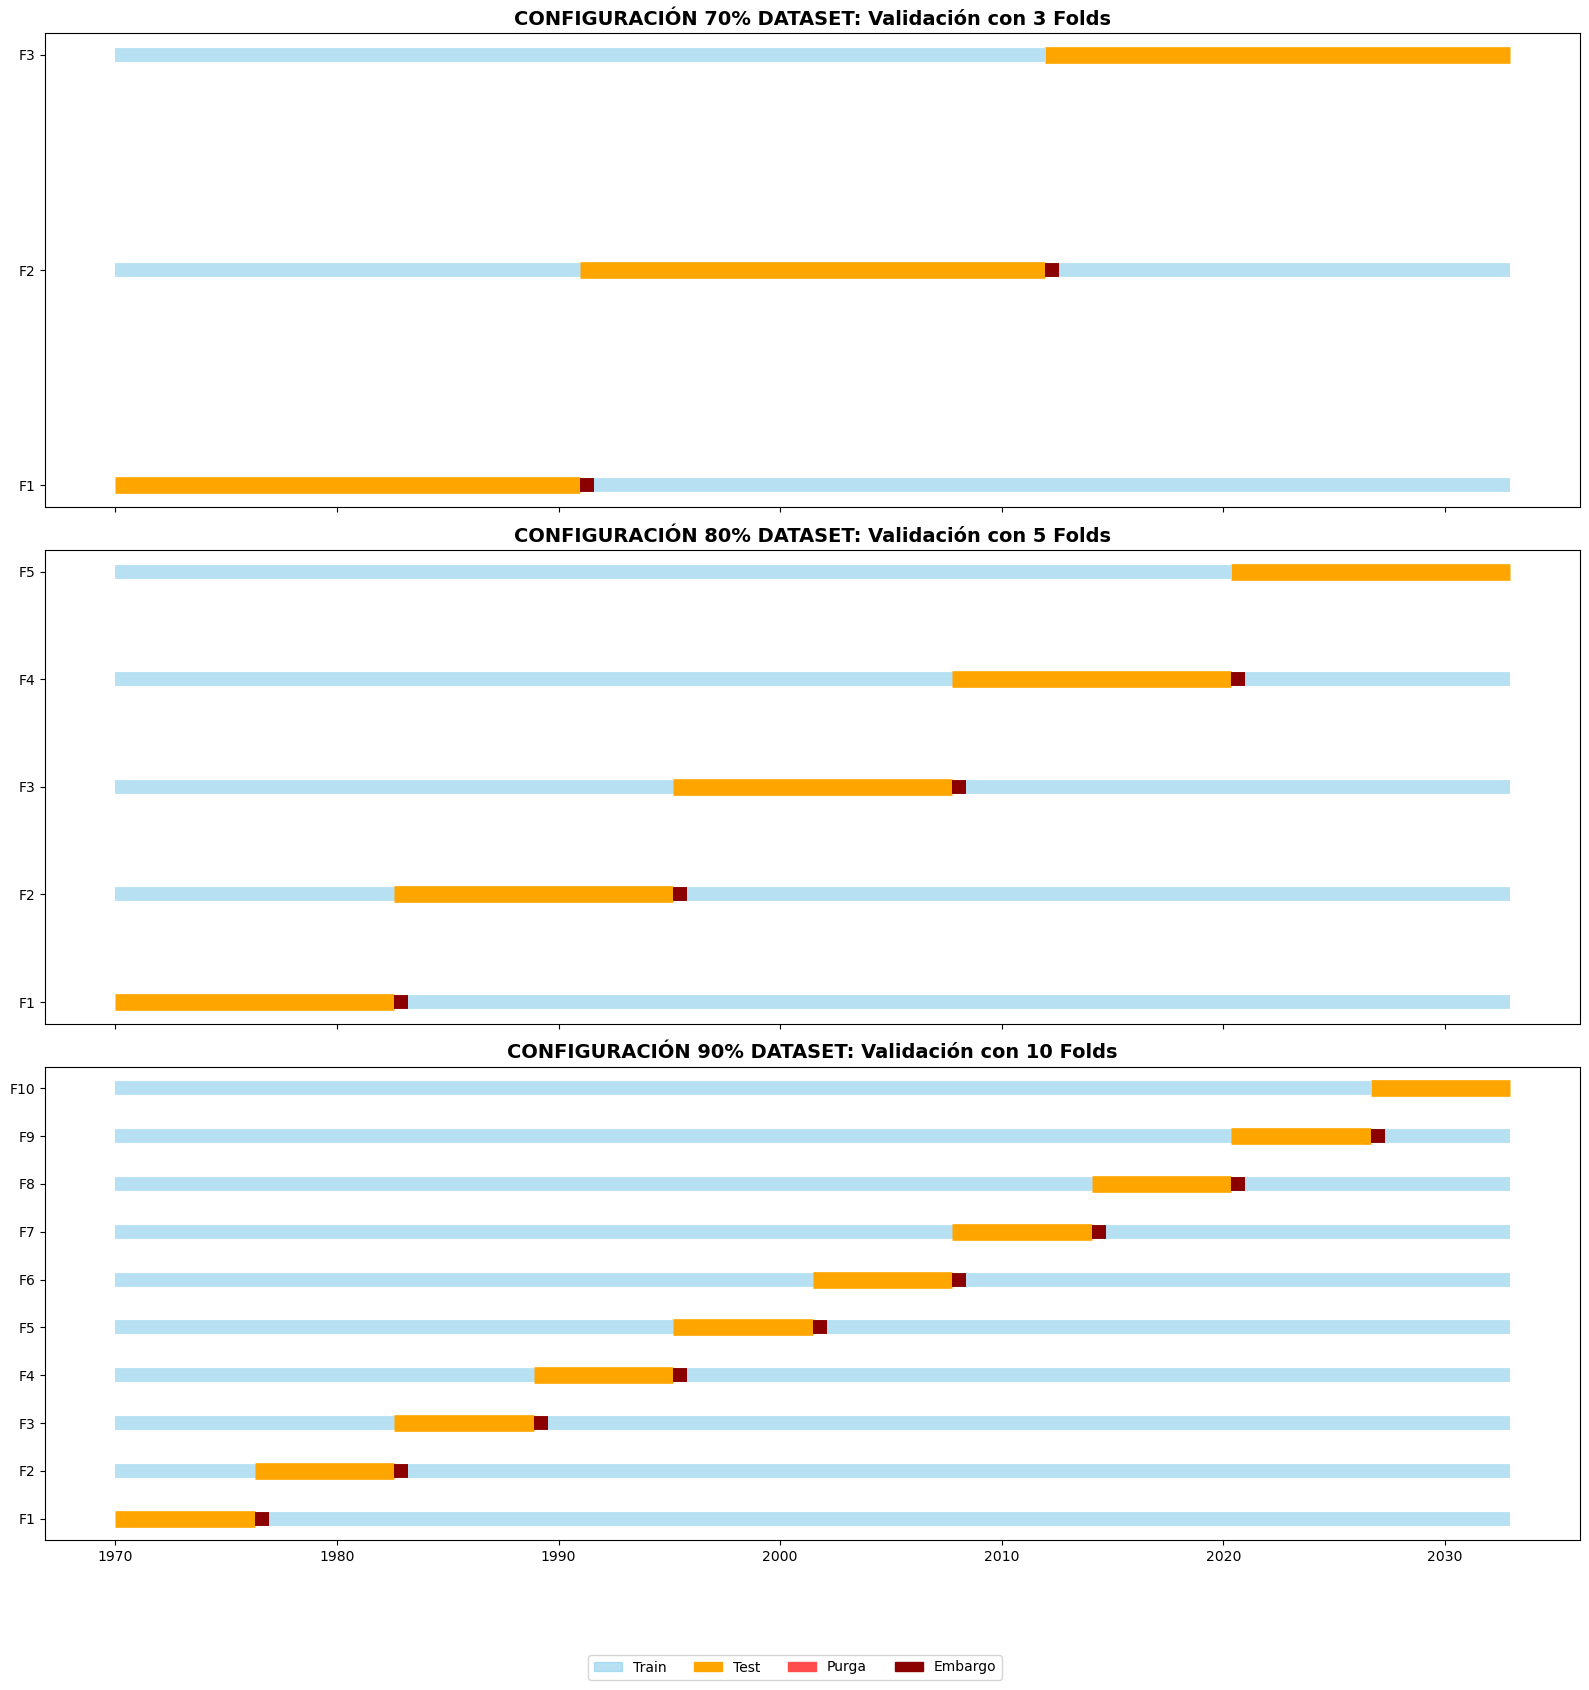

In [ ]:
def get_cv_labels_visual(t1, test_idx, pct_embargo=0.01, visual_extra_purge=0.02):
    """
    Función auxiliar para calcular los índices de Train, Test, Purga y Embargo.
    """
    # Índices numéricos del test
    test = set(test_idx)
    
    # Determinamos los límites temporales del test para purgar
    test_times = t1.iloc[test_idx]
    test_start = test_times.index.min()
    test_end = test_times.max() # Basado en t1 (final de la barrera vertical)
    
    # 1. PURGA (Datos que terminan después de que empiece el test)
    # Buscamos eventos que empezaron antes del test pero terminan dentro del test
    purge = set(t1[(t1 > test_start) & (t1.index < test_start)].index)
    
    # 2. EMBARGO (Datos que empiezan justo después del test)
    embargo_period = int(len(t1) * pct_embargo)
    last_test_idx = test_idx[-1]
    embargo_idx = np.arange(last_test_idx + 1, min(last_test_idx + 1 + embargo_period, len(t1)))
    embargo = set(embargo_idx)
    
    # 3. TRAIN (Todo lo que no es test, ni purga, ni embargo)
    all_indices = set(np.arange(len(t1)))
    train = all_indices - test - purge - embargo
    
    # Convertimos a listas para matplotlib
    return list(train), list(test), list(purge), list(embargo)

def plot_enhanced_cv_proportional(t1, proportions=[0.7, 0.8, 0.9]):
    # Definimos un número de Folds distinto para cada proporción
    folds_por_proporcion = {0.7: 3, 0.8: 5, 0.9: 10}
    
    fig, axes = plt.subplots(len(proportions), 1, figsize=(16, 6 * len(proportions)), sharex=True)
    c_train, c_test, c_purge, c_embargo = 'skyblue', 'orange', '#ff4d4d', '#8b0000'

    for idx, pct in enumerate(proportions):
        ax = axes[idx]
        n_splits = folds_por_proporcion[pct] # Aquí está el cambio clave
        indices = np.arange(len(t1))
        kf = KFold(n_splits=n_splits)
        
        for i, (_, test_idx) in enumerate(kf.split(indices)):
            train, test, purge, embargo = get_cv_labels_visual(t1, test_idx, pct_embargo=0.01, visual_extra_purge=0.02)
            
            if train: ax.hlines(i, min(train), max(train), colors=c_train, lw=10, alpha=0.6)
            if purge: ax.hlines(i, min(purge), max(purge), colors=c_purge, lw=10)
            if test: ax.hlines(i, min(test), max(test), colors=c_test, lw=12)
            if embargo: ax.hlines(i, min(embargo), max(embargo), colors=c_embargo, lw=10)

        ax.set_title(f"CONFIGURACIÓN {int(pct*100)}% DATASET: Validación con {n_splits} Folds", 
                     fontsize=14, fontweight='bold')
        ax.set_yticks(range(n_splits))
        ax.set_yticklabels([f'F{i+1}' for i in range(n_splits)])

    # Leyenda manual (igual que antes)
    legend_elements = [
        mpatches.Patch(color=c_train, alpha=0.6, label='Train'),
        mpatches.Patch(color=c_test, label='Test'),
        mpatches.Patch(color=c_purge, label='Purga'),
        mpatches.Patch(color=c_embargo, label='Embargo')
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=4, bbox_to_anchor=(0.5, 0.02))
    plt.tight_layout(rect=[0, 0.08, 1, 0.96])
    plt.show()

plot_enhanced_cv_proportional(events['t1'])

En el gráfico superior se observa como cambiaría la asignación de los diferentes conjuntos de datos en función del parámetro k. Este parámetro determina particiones habrá que hacer sobre los datos. En este caso se han seleccionado los parámetros 3,5 y 10.

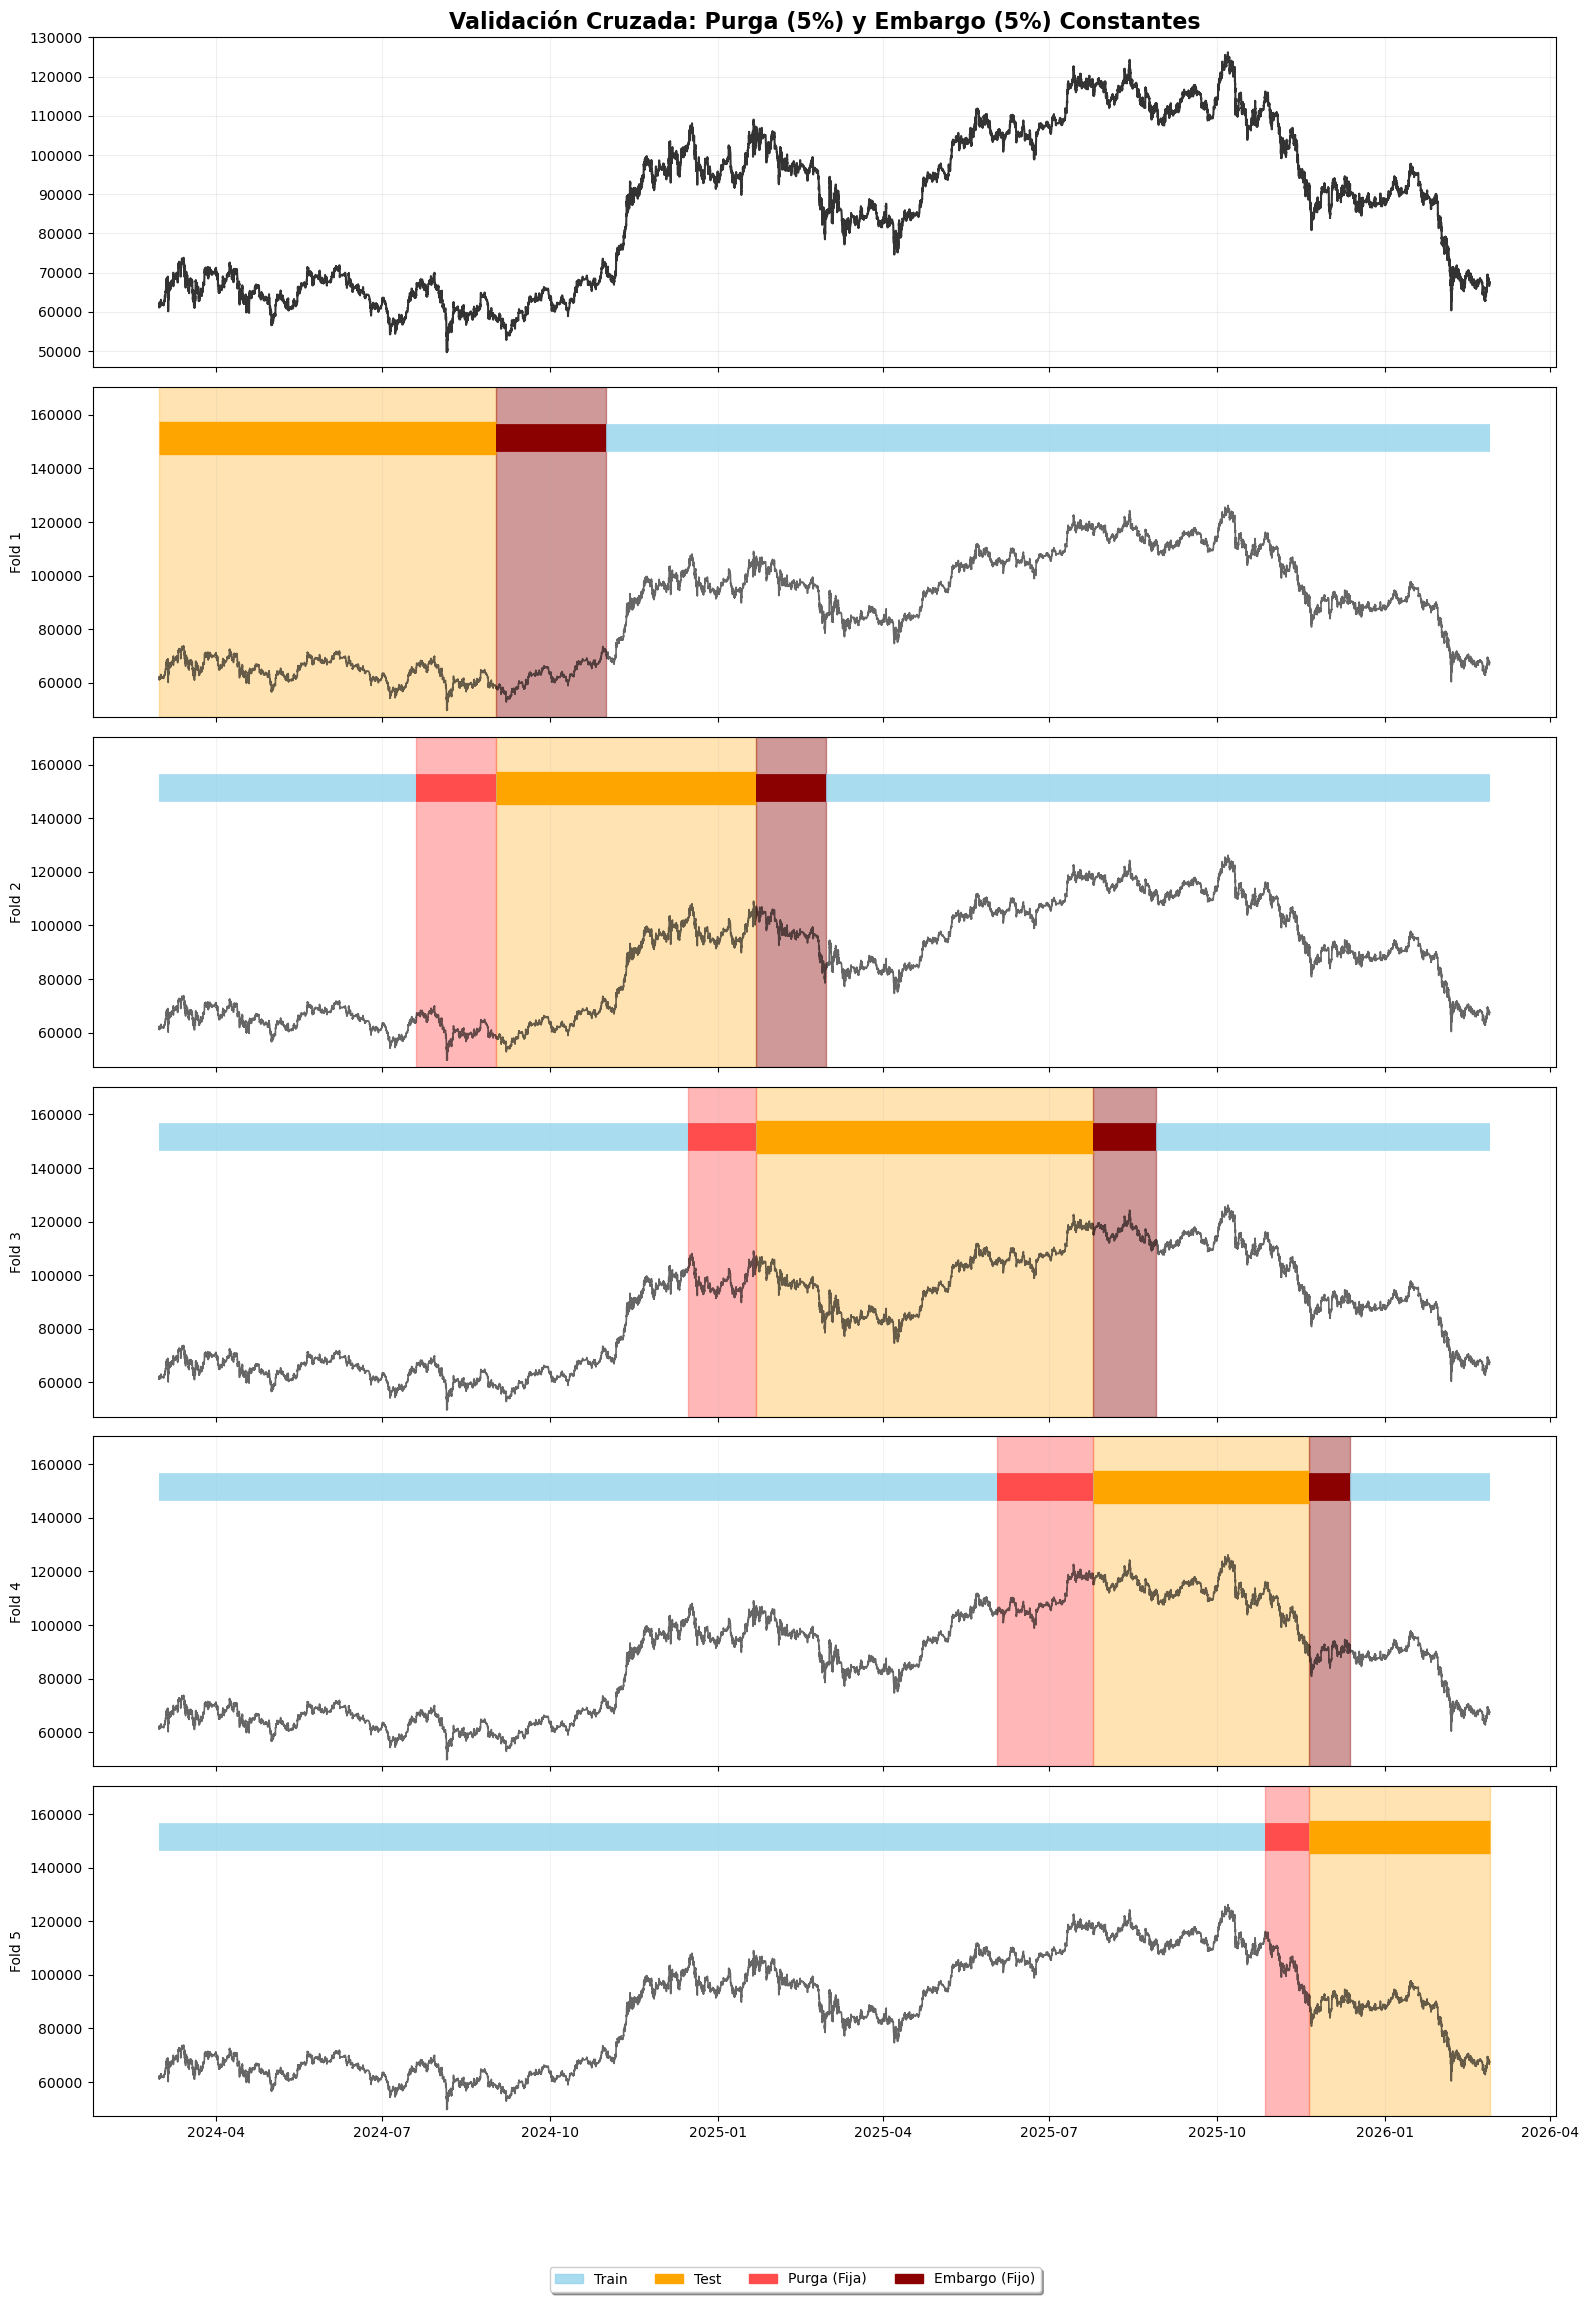

In [ ]:
def get_cv_labels_fixed_proportions(t1, test_idx, pct_purge=0.05, pct_embargo=0.05):
    """
    Calcula Train, Test, Purge y Embargo asegurando que Purga y Embargo 
    tengan siempre el mismo tamaño relativo al dataset total.
    """
    all_indices = np.arange(len(t1))
    
    # 1. Definir Test
    test_idx_list = list(test_idx)
    
    # 2. Definir Purga (Tamaño fijo ANTES del Test)
    # Calculamos cuántas muestras representan el pct_purge
    purge_size = int(len(t1) * pct_purge)
    first_test_idx = test_idx[0]
    
    # La purga son los N índices previos al inicio del test
    purge_idx = np.arange(max(0, first_test_idx - purge_size), first_test_idx)
    
    # 3. Definir Embargo (Tamaño fijo DESPUÉS del Test)
    embargo_size = int(len(t1) * pct_embargo)
    last_test_idx = test_idx[-1]
    
    # El embargo son los N índices posteriores al fin del test
    embargo_idx = np.arange(last_test_idx + 1, min(last_test_idx + 1 + embargo_size, len(t1)))
    
    # 4. Definir Train (Lo que sobra)
    test_set = set(test_idx)
    purge_set = set(purge_idx)
    embargo_set = set(embargo_idx)
    
    train_idx = sorted(list(set(all_indices) - test_set - purge_set - embargo_set))
    
    # Convertir a Timestamps para el gráfico de precios
    return {
        'train': list(t1.index[train_idx]),
        'test': list(t1.index[test_idx_list]),
        'purge': list(t1.index[purge_idx]),
        'embargo': list(t1.index[embargo_idx])
    }

# ========================================================
# 2. FUNCIÓN DE GRAFICADO UNIFICADA
# ========================================================
def plot_cv_final_fixed_ratios(price_serie, t1, n_splits=5, p_size=0.05, e_size=0.05):
    kf = KFold(n_splits=n_splits)
    fig, axes = plt.subplots(n_splits + 1, 1, figsize=(16, 4 * (n_splits + 1)), sharex=True)
    
    # Colores consistentes con tus entregas anteriores
    c_train, c_test, c_purge, c_embargo = 'skyblue', 'orange', '#ff4d4d', '#8b0000'
    c_base = 'black'

    # Subplot superior: Serie Completa
    axes[0].plot(price_serie.index, price_serie.values, color=c_base, lw=1.5, alpha=0.8)
    axes[0].set_title(f"Validación Cruzada: Purga ({int(p_size*100)}%) y Embargo ({int(e_size*100)}%) Constantes", 
                      fontsize=16, fontweight='bold')
    axes[0].grid(alpha=0.2)

    for i, (_, test_idx_raw) in enumerate(kf.split(price_serie.index)):
        ax = axes[i + 1]
        
        # Obtenemos etiquetas con proporciones fijas
        res = get_cv_labels_fixed_proportions(t1, test_idx_raw, pct_purge=p_size, pct_embargo=e_size)
        
        # Dibujamos el precio de fondo
        ax.plot(price_serie.index, price_serie.values, color=c_base, lw=1.2, alpha=0.6)

        # Sombreados de fondo (ahora siempre medirán lo mismo visualmente)
        if res['test']: ax.axvspan(min(res['test']), max(res['test']), color=c_test, alpha=0.3)
        if res['purge']: ax.axvspan(min(res['purge']), max(res['purge']), color=c_purge, alpha=0.4)
        if res['embargo']: ax.axvspan(min(res['embargo']), max(res['embargo']), color=c_embargo, alpha=0.4)

        # Barras de estructura
        y_pos = price_serie.max() * 1.20
        lw_bar = 20
        if res['train']: ax.hlines(y_pos, min(res['train']), max(res['train']), colors=c_train, lw=lw_bar, alpha=0.7)
        if res['purge']: ax.hlines(y_pos, min(res['purge']), max(res['purge']), colors=c_purge, lw=lw_bar)
        if res['test']: ax.hlines(y_pos, min(res['test']), max(res['test']), colors=c_test, lw=lw_bar + 4)
        if res['embargo']: ax.hlines(y_pos, min(res['embargo']), max(res['embargo']), colors=c_embargo, lw=lw_bar)

        ax.set_ylim(price_serie.min() * 0.95, price_serie.max() * 1.35)
        ax.set_ylabel(f"Fold {i+1}")
        ax.grid(axis='x', alpha=0.15)

    # Leyenda y estética final
    legend_elements = [
        mpatches.Patch(color=c_train, alpha=0.7, label='Train'),
        mpatches.Patch(color=c_test, label='Test'),
        mpatches.Patch(color=c_purge, label='Purga (Fija)'),
        mpatches.Patch(color=c_embargo, label='Embargo (Fijo)')
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=4, bbox_to_anchor=(0.5, 0.02), shadow=True)
    
    plt.tight_layout(rect=[0, 0.08, 1, 0.98])
    plt.show()

# Ejecución (Ejemplo con 5% de Purga y 5% de Embargo)
plot_cv_final_fixed_ratios(close_btc.loc[events.index], events['t1'], n_splits=5, p_size=0.05, e_size=0.05)

Por último, se aprecia la selección de los conjuntos de datos para una validación cruzada (k=5) sobre los precios de BTC. Aparecen remarcados los conjuntos de datos test, purga y embargo. Estos dos últimos no se utilizarían en el modelo.